# IMPORTAR MATRIZ M

In [33]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import NMF as skNMF
import os
%matplotlib inline

In [2]:
sys.path.insert(0, r"C:\Users\quiqu\OneDrive\Escritorio\GITHUB\SigProfilerExtractor_Noise")

BASE = r"C:\Users\quiqu\OneDrive\Escritorio\GITHUB\SigProfilerExtractor_Noise\Analisis Quique"
SEED = 42

ruta = os.path.join(BASE, "data", "PCAWG_2583_SBS96.txt")
M_df_full = pd.read_csv(ruta, sep='\t', index_col=0)
coad_cols = [col for col in M_df_full.columns if col.startswith("LUAD") or col.startswith("LUSC")]
M_df = M_df_full[coad_cols]
M = M_df.values.astype(float)
n_mut, n_tum = M.shape

ruta_pulmon = os.path.join(BASE, "data", "PULMON_84.txt")
M_df.to_csv(ruta_pulmon, sep='\t')

print(f"M: {M.shape}")

M: (96, 84)


In [3]:
M_df

,LUAD.US_SP50827,LUAD.US_SP50263,LUAD.US_SP50317,LUAD.US_SP54113,LUSC.US_SP56537,LUAD.US_SP50406,LUSC.US_SP57586,LUAD.US_SP51824,LUAD.US_SP55387,LUAD.US_SP52779,...,LUAD.US_SP52667,LUSC.US_SP57450,LUSC.US_SP57846,LUSC.US_SP58612,LUSC.US_SP56821,LUAD.US_SP51446,LUAD.US_SP50592,LUAD.US_SP53073,LUSC.US_SP58882,LUSC.US_SP57189
MutationType,,,,,,,,,,,,,,,,,,,,,
A[C>A]A,1727,217,331,4163,1691,13,1168,601,969,1631,...,1304,437,1165,879,1034,119,95,723,528,4590
A[C>A]C,1164,136,183,2514,984,5,668,413,546,957,...,917,249,791,556,603,94,50,507,295,2688
A[C>A]G,429,38,35,998,376,0,262,156,197,437,...,359,86,346,217,234,21,16,173,103,1014
A[C>A]T,1167,130,219,2547,1093,7,699,401,643,1074,...,906,263,748,478,653,73,52,452,320,2800
A[C>G]A,413,106,113,1377,510,5,412,201,260,305,...,310,205,378,294,337,23,26,162,212,1503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
T[T>C]T,220,109,111,648,321,6,420,164,112,168,...,128,208,277,247,266,61,84,214,404,761
T[T>G]A,86,36,39,286,134,2,184,70,39,94,...,63,78,119,85,117,22,25,46,128,299
T[T>G]C,35,37,30,128,58,1,82,38,31,39,...,36,44,69,54,43,15,15,47,81,93


In [4]:
RESIDUALS_DIR = r"C:\Users\quiqu\OneDrive\Escritorio\GITHUB\SigProfilerExtractor_Noise\SigProfilerExtractor\_residuals"
K_FILE = r"C:\Users\quiqu\OneDrive\Escritorio\GITHUB\SigProfilerExtractor_Noise\SigProfilerExtractor\_current_k.txt"

os.makedirs(RESIDUALS_DIR, exist_ok=True)
print("Rutas OK")

Rutas OK


In [5]:
U_POR_K_DIR = os.path.join(BASE, "resultados", "extraccion_pulmon_1_15", "SBS96", "U_por_K")

for k in range(1, 16):
    U_df = pd.read_csv(os.path.join(U_POR_K_DIR, f"U_K{k}.csv"), index_col=0)
    U_arr = U_df.values.astype(float)
    SA = M - U_arr
    
    np.save(os.path.join(RESIDUALS_DIR, f"SA_k{k}.npy"), SA)
    np.save(os.path.join(RESIDUALS_DIR, f"U_k{k}.npy"), U_arr)
    
    print(f"K={k} — media U: {U_arr.mean():.6f} — guardado OK")

print("Pre-cálculo completado")

K=1 — media U: -0.000003 — guardado OK
K=2 — media U: 0.000007 — guardado OK
K=3 — media U: -0.000003 — guardado OK
K=4 — media U: 0.000001 — guardado OK
K=5 — media U: 0.000003 — guardado OK
K=6 — media U: 0.000003 — guardado OK
K=7 — media U: -0.000000 — guardado OK
K=8 — media U: -0.000001 — guardado OK
K=9 — media U: 0.000001 — guardado OK
K=10 — media U: -0.000001 — guardado OK
K=11 — media U: 0.000002 — guardado OK
K=12 — media U: -0.000000 — guardado OK
K=13 — media U: 0.000003 — guardado OK
K=14 — media U: -0.000000 — guardado OK
K=15 — media U: 0.000000 — guardado OK
Pre-cálculo completado


In [6]:
from SigProfilerExtractor import sigpro as sig

output_residual = os.path.join(BASE, "resultados", "extraccion_residual")
os.makedirs(output_residual, exist_ok=True)

if os.path.exists(os.path.join(output_residual, "SBS96")):
    print("Extracción residual ya realizada, saltando.")
else:
    sig.sigProfilerExtractor(
        input_type="matrix",
        output=output_residual,
        input_data=ruta_pulmon,
        reference_genome="GRCh37",
        minimum_signatures=1,
        maximum_signatures=15,
        nmf_replicates=100
    )

Extracción residual ya realizada, saltando.


# NUEVO REMUESTREO

# HACER EL NMF CON SIPROFILEXTRACTOR

In [7]:
# from SigProfilerExtractor import sigpro as sig
# import os

# output = os.path.join(BASE, "resultados", "extraccion_pulmon")

# if os.path.exists(os.path.join(output, "SBS96")):
#     print("Extracción ya realizada, saltando.")
# else:
#     os.makedirs(output, exist_ok=True)
#     sig.sigProfilerExtractor(
#         input_type="matrix",
#         output=output,
#         input_data=ruta_pulmon,
#         reference_genome="GRCh37",
#         minimum_signatures=1,
#         maximum_signatures=10,
#         nmf_replicates=100
#     )

# RESULTADOS DE NOVO

Matrices A y S

In [8]:
base_denovo = os.path.join(BASE, "resultados", "extraccion_residual", "SBS96", "Suggested_Solution", "SBS96_De-Novo_Solution")

# Cargar S y A de novo
S_denovo_df = pd.read_csv(base_denovo + r"\Signatures\SBS96_De-Novo_Signatures.txt", sep="\t", index_col=0)
A_denovo_df = pd.read_csv(base_denovo + r"\Activities\SBS96_De-Novo_Activities_refit.txt", sep="\t", index_col=0)
S_sem_df    = pd.read_csv(base_denovo + r"\Signatures\SBS96_De-Novo_Signatures_SEM_Error.txt", sep="\t", index_col=0)

print("S de novo:", S_denovo_df.shape)
print("A de novo:", A_denovo_df.shape)
print("SEM de S: ", S_sem_df.shape)

S_denovo_df.head()

S de novo: (96, 3)
A de novo: (84, 3)
SEM de S:  (96, 3)


,SBS96A,SBS96B,SBS96C
MutationType,,,
A[C>A]A,0.046720,0.014195,0.006876
A[C>A]C,0.028920,0.007641,0.004563
A[C>A]G,0.011600,0.001920,0.000911
A[C>A]T,0.030992,0.007442,0.004339
A[C>G]A,0.011562,0.009231,0.003644


Firmas Asignadas

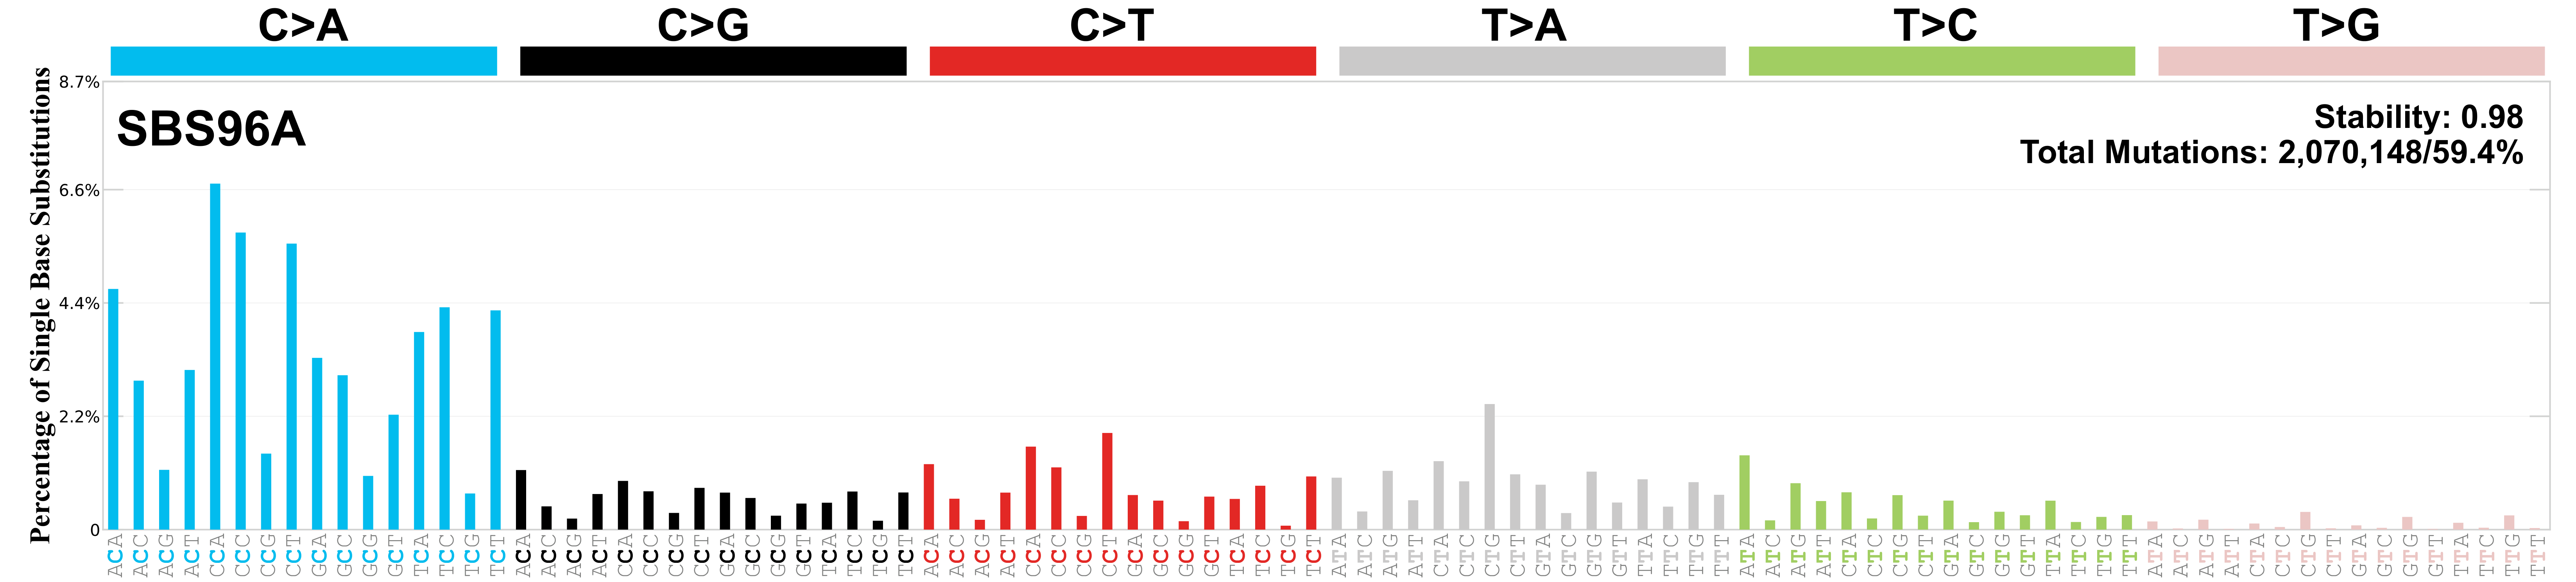

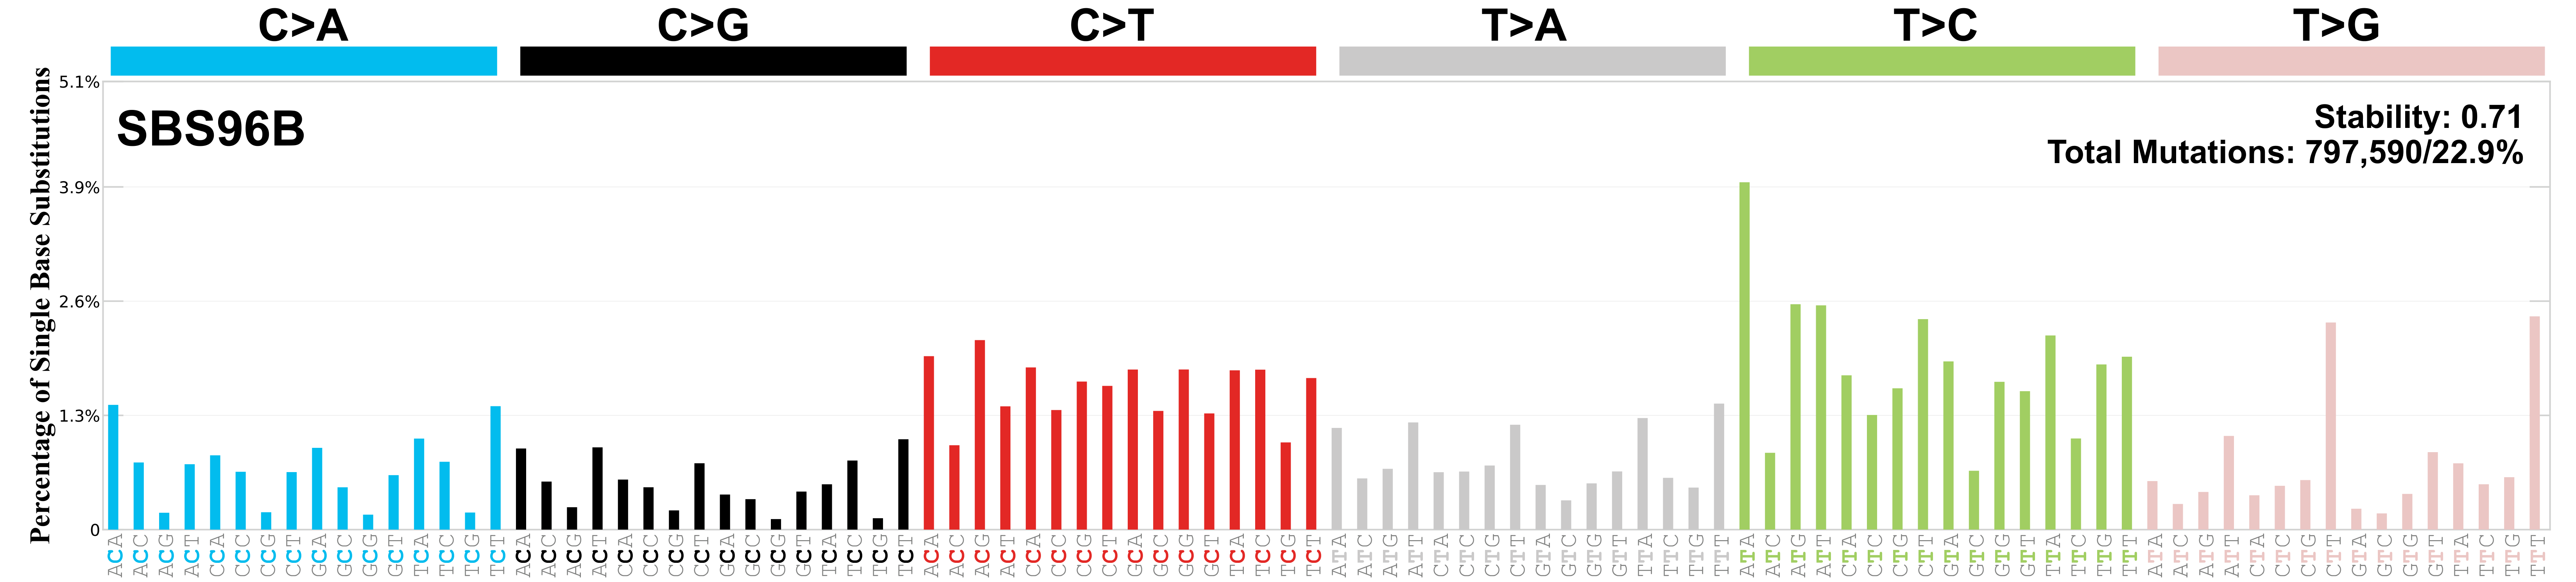

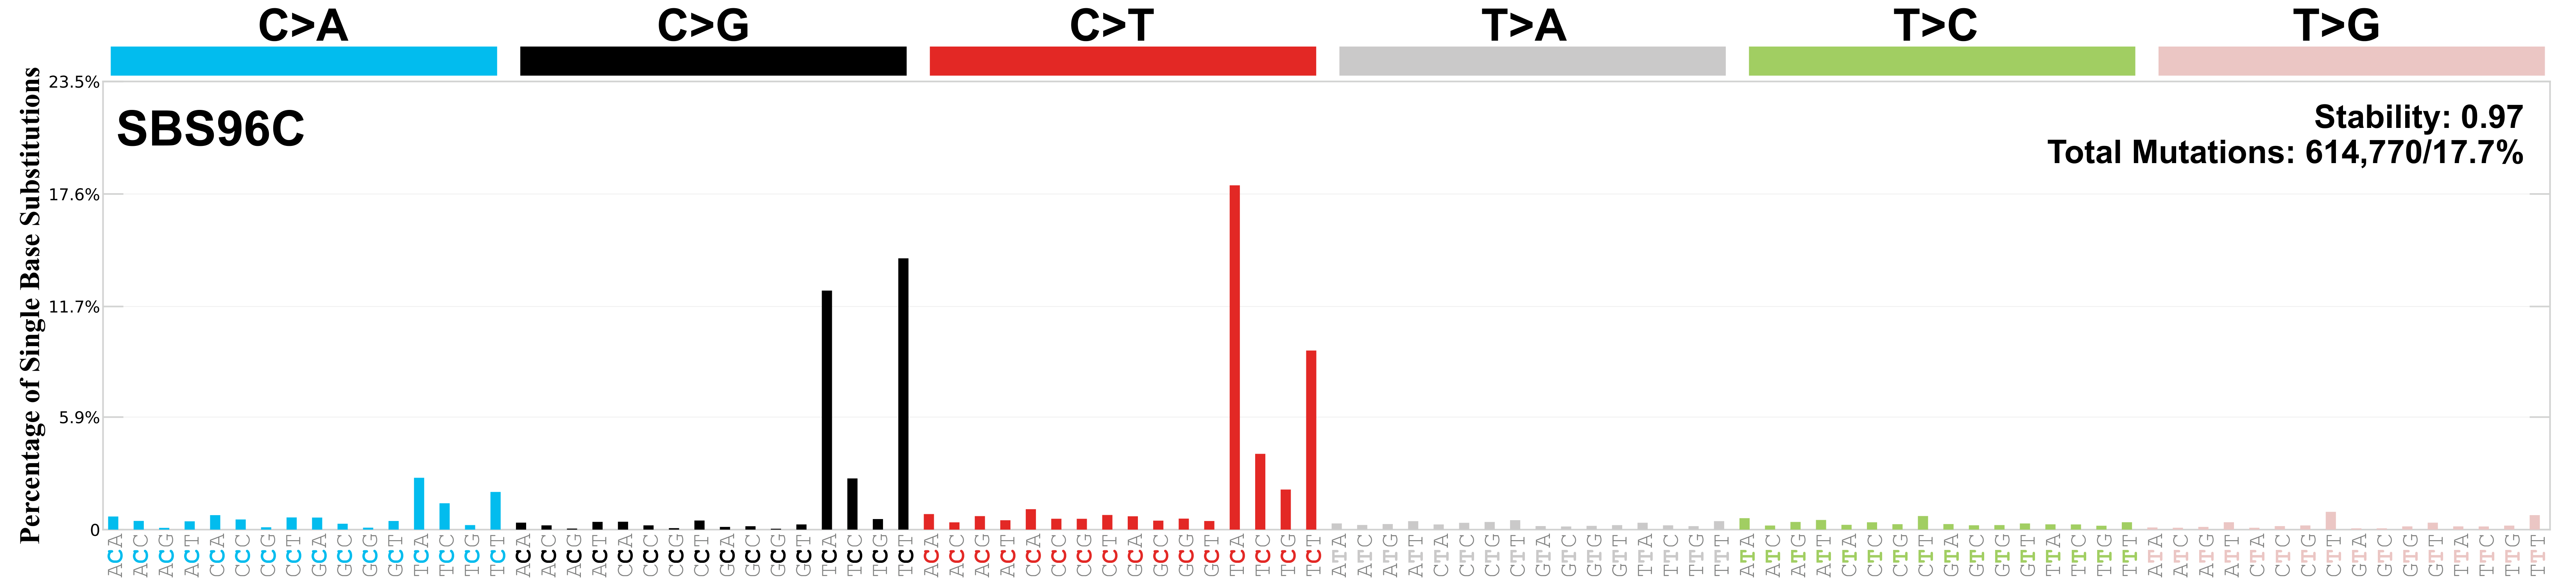

In [9]:
from IPython.display import Image
import fitz  # pip install pymupdf

# Convertir primera página del PDF a imagen
pdf_path = base_denovo + r"\Signatures\SBS_96_plots_SBS96_De-Novo.pdf"
doc = fitz.open(pdf_path)

for i, page in enumerate(doc):
    pix = page.get_pixmap(dpi=150)
    display(Image(data=pix.tobytes("png"), format='png'))

Explicación del número de firmas

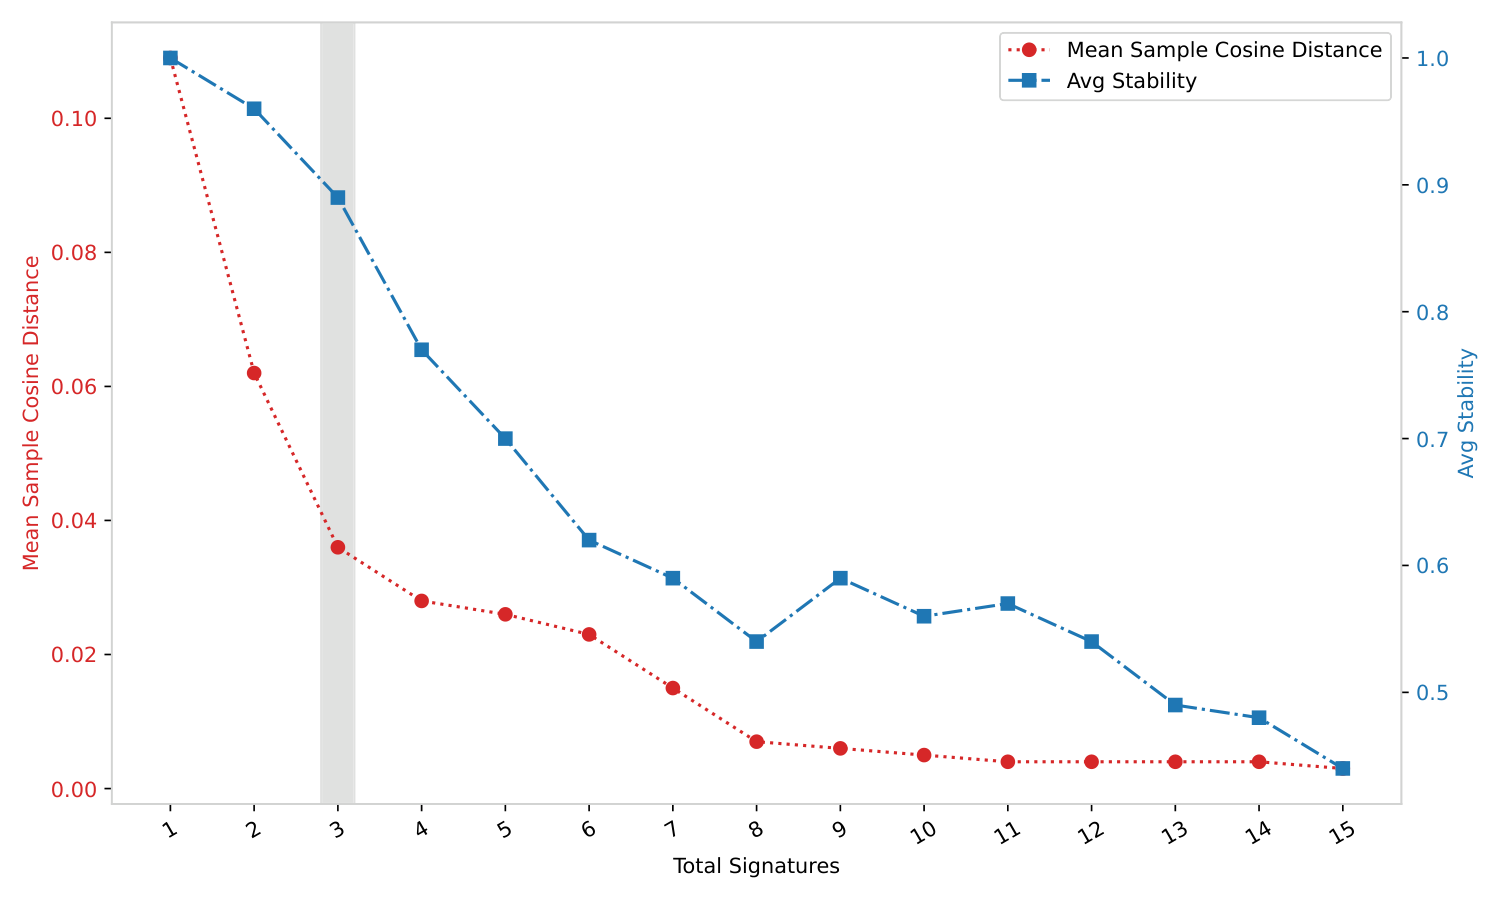

In [10]:
base_output = output_residual  # = os.path.join(BASE, "resultados", "extraccion_pulmon")

pdf_path = os.path.join(base_output, "SBS96", "SBS96_selection_plot.pdf")
doc = fitz.open(pdf_path)
for page in doc:
    pix = page.get_pixmap(dpi=150)
    display(Image(data=pix.tobytes("png"), format='png'))

Qué firmas se han detectado en cada tumor (146 tumores repartidos en 3 paginas)

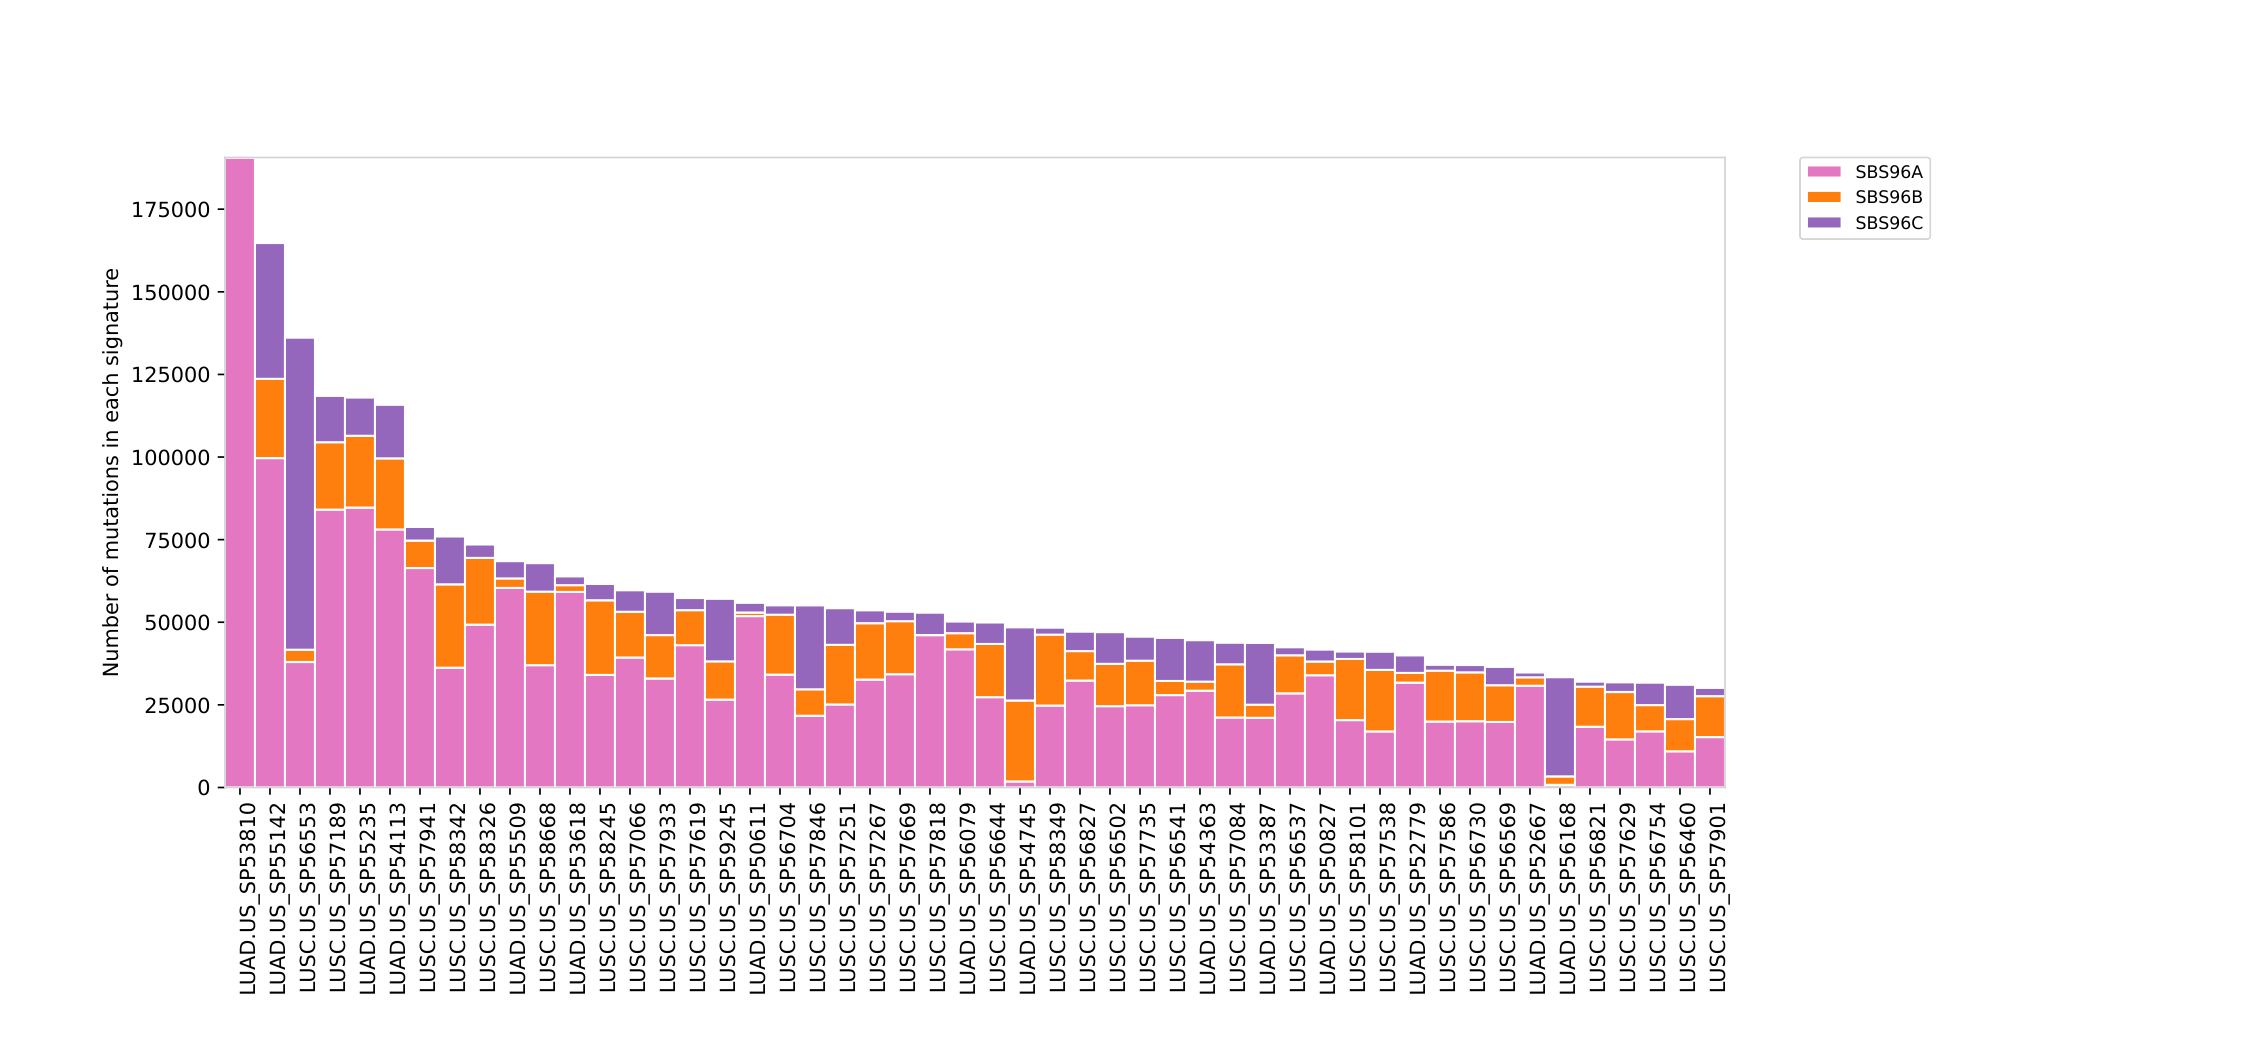

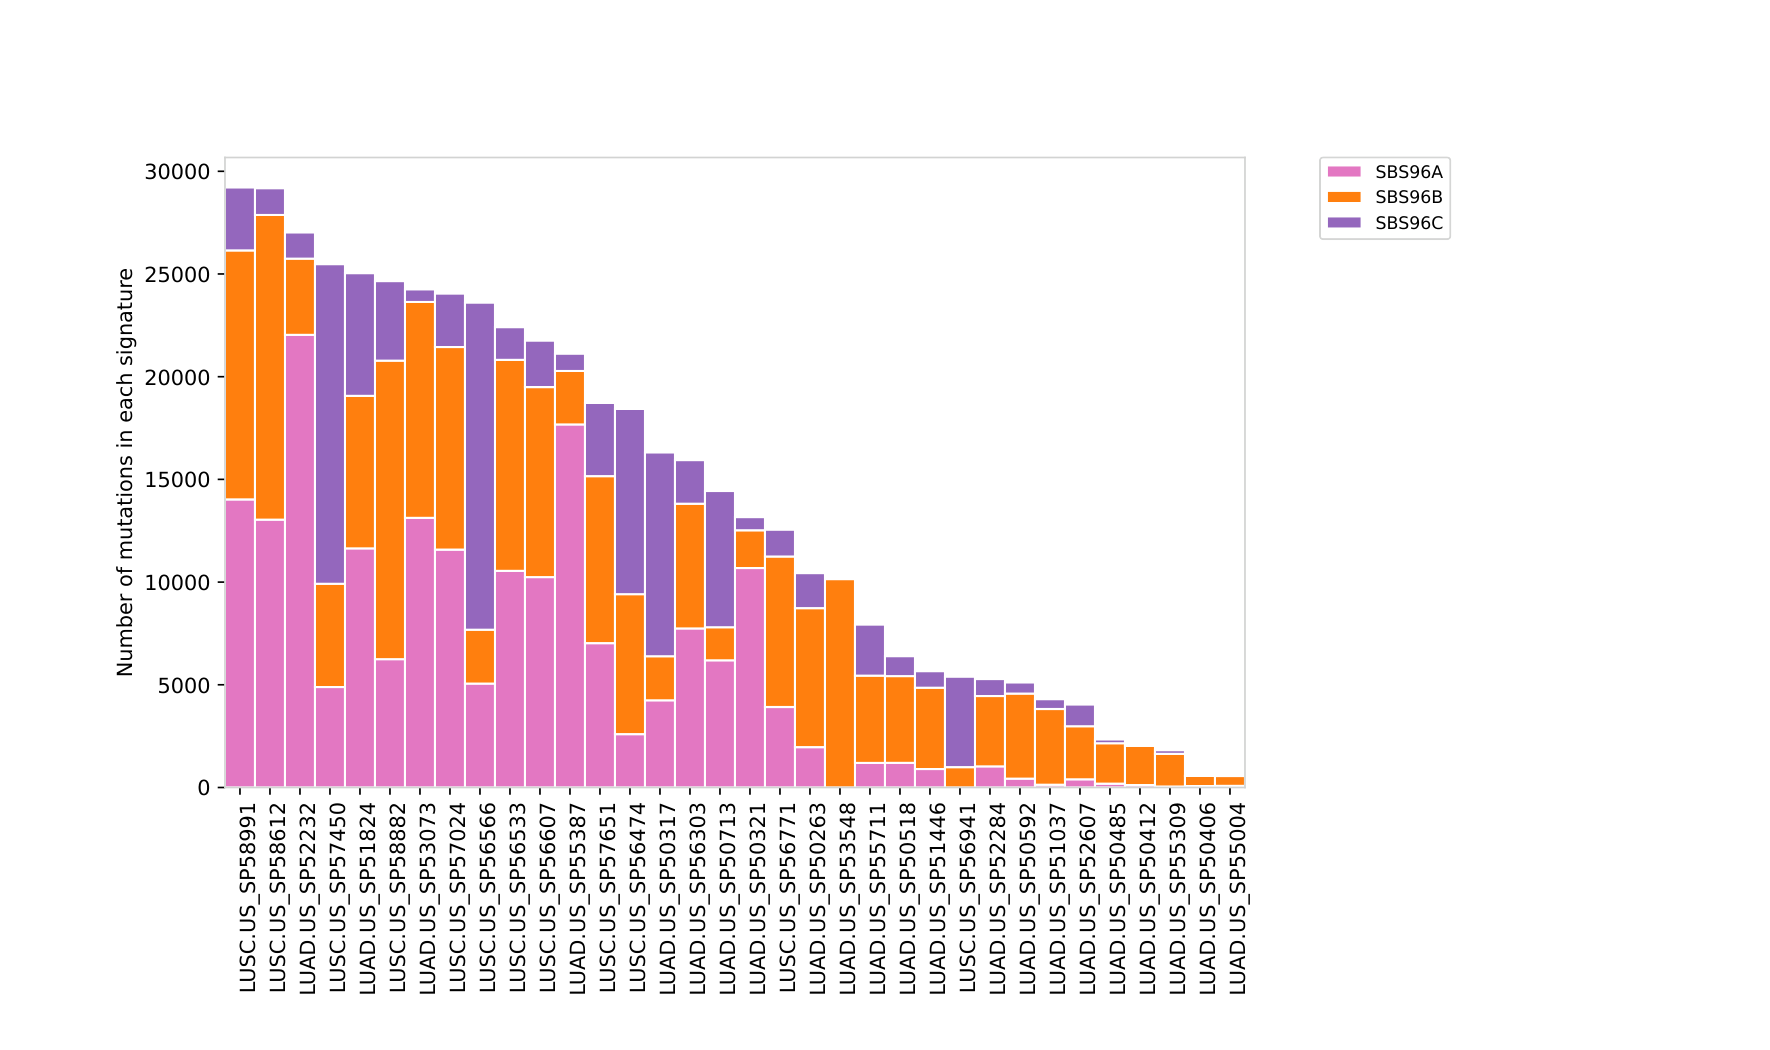

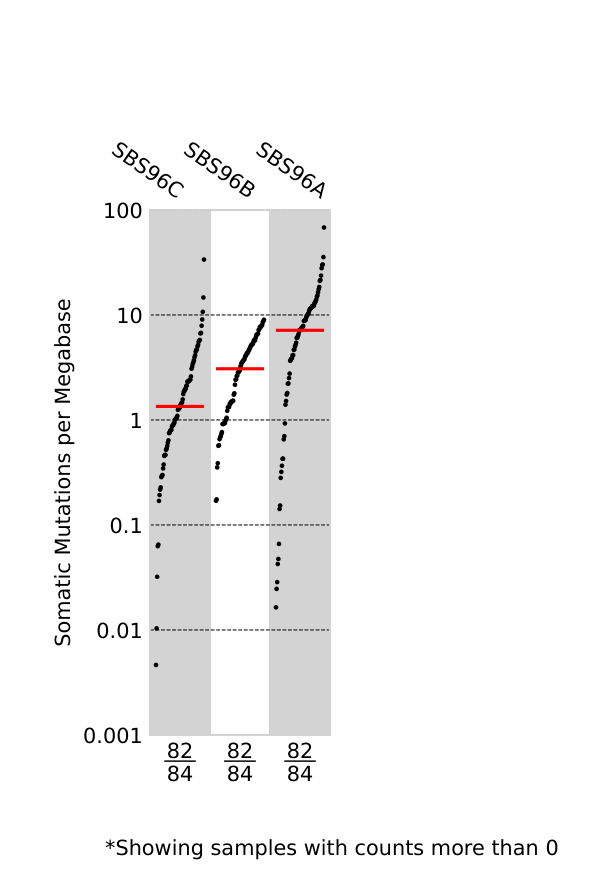

In [11]:
pdfs = [
    base_denovo + r"\Activities\SBS96_De-Novo_Activity_Plots_refit.pdf",
    base_denovo + r"\Activities\SBS96_De-Novo_TMB_plot_refit.pdf",
]

for pdf_path in pdfs:
    doc = fitz.open(pdf_path)
    for page in doc:
        pix = page.get_pixmap(dpi=150)
        display(Image(data=pix.tobytes("png"), format='png'))

# Correlación

## Matriz M

### Entre tumores (columnas)

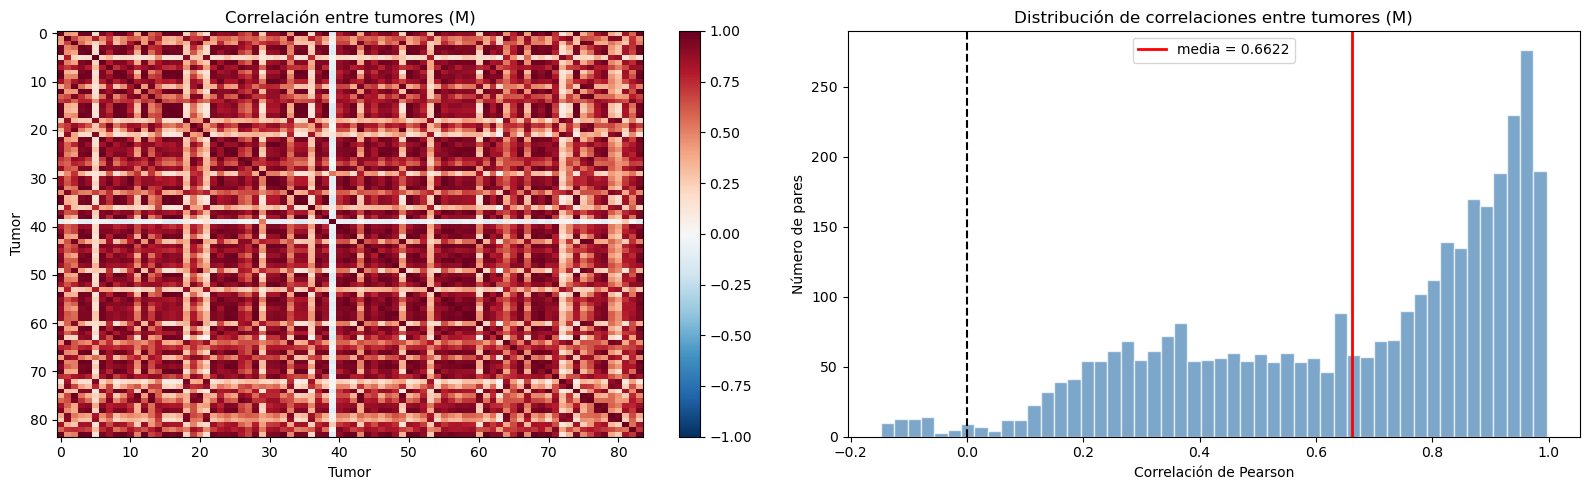

Correlación media: 0.6622
% pares con |corr| > 0.3: 85.6%
% pares con |corr| > 0.5: 70.1%


In [49]:
# Matriz de correlación de M (entre tumores/columnas)
corr_M = np.corrcoef(M.T)  # (146, 146)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im = axes[0].imshow(corr_M, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[0].set_title('Correlación entre tumores (M)')
axes[0].set_xlabel('Tumor')
axes[0].set_ylabel('Tumor')
plt.colorbar(im, ax=axes[0])

corr_offdiag = corr_M[np.triu_indices(n_tum, k=1)]
axes[1].hist(corr_offdiag, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].axvline(corr_offdiag.mean(), color='red', linewidth=2,
                label=f'media = {corr_offdiag.mean():.4f}')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Correlación de Pearson')
axes[1].set_ylabel('Número de pares')
axes[1].set_title('Distribución de correlaciones entre tumores (M)')
axes[1].legend()

plt.tight_layout()
plt.show()
plt.close('all')

print(f"Correlación media: {corr_offdiag.mean():.4f}")
print(f"% pares con |corr| > 0.3: {(np.abs(corr_offdiag) > 0.3).mean()*100:.1f}%")
print(f"% pares con |corr| > 0.5: {(np.abs(corr_offdiag) > 0.5).mean()*100:.1f}%")

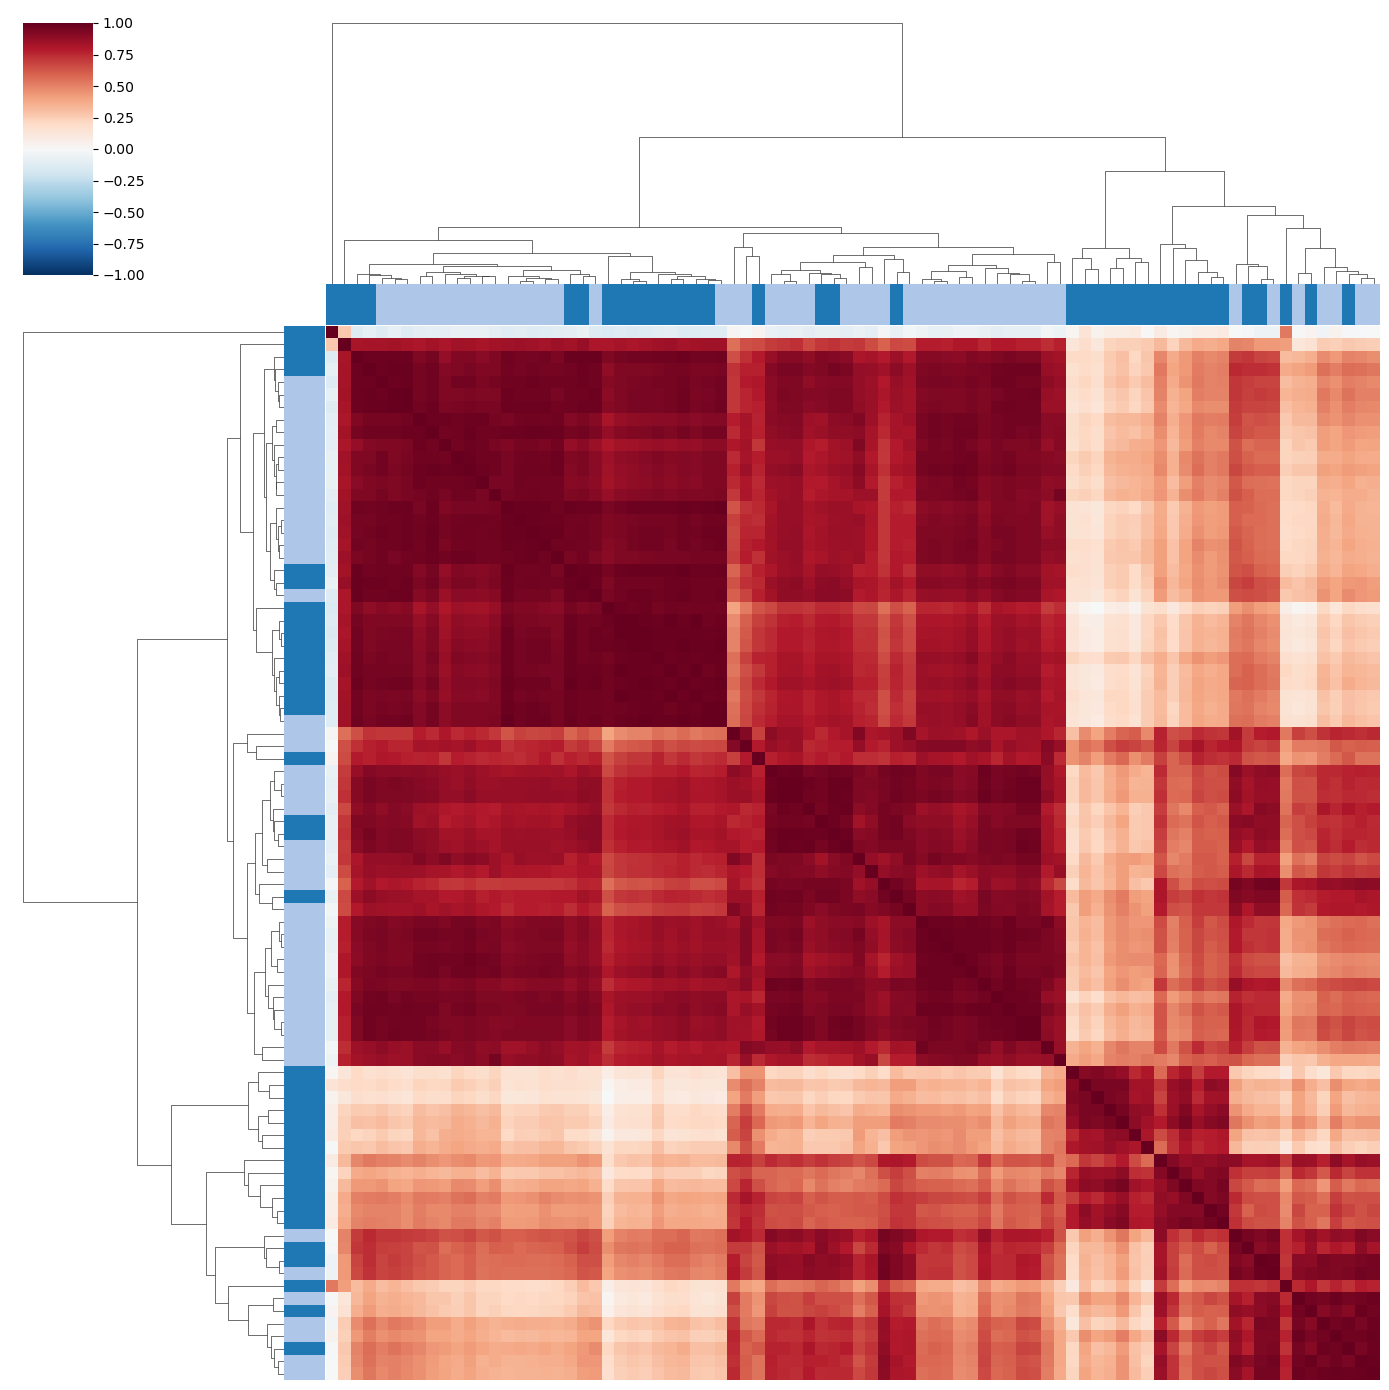

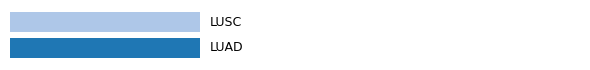

In [50]:
import seaborn as sns

# Extraer tipo de cáncer del nombre de cada muestra
cancer_types = [col.split(".")[0] for col in M_df.columns]

# Crear paleta de colores por tipo de cáncer
tipos_unicos = list(set(cancer_types))
palette = sns.color_palette("tab20", len(tipos_unicos))
color_map = dict(zip(tipos_unicos, palette))
col_colors = [color_map[t] for t in cancer_types]

# Clustermap
sns.clustermap(pd.DataFrame(corr_M, index=M_df.columns, columns=M_df.columns),
               cmap='RdBu_r', vmin=-1, vmax=1,
               col_colors=col_colors, row_colors=col_colors,
               figsize=(14, 14), xticklabels=False, yticklabels=False)
plt.show()
plt.close('all')

# Leyenda
fig, ax = plt.subplots(figsize=(6, len(tipos_unicos) * 0.4))
for i, (tipo, color) in enumerate(color_map.items()):
    ax.barh(i, 1, color=color)
    ax.text(1.05, i, tipo, va='center', fontsize=9)
ax.set_xlim(0, 3)
ax.axis('off')
plt.tight_layout()
plt.show()

### Entre tipos de mutacion (filas)

In [14]:
# Matriz de correlación de M (entre tipos de mutación/filas)
corr_M_filas = np.corrcoef(M)  # (96, 96)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im = axes[0].imshow(corr_M_filas, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[0].set_title('Correlación entre tipos de mutación (M)')
axes[0].set_xlabel('Tipo de mutación')
axes[0].set_ylabel('Tipo de mutación')
plt.colorbar(im, ax=axes[0])

corr_offdiag_filas = corr_M_filas[np.triu_indices(n_mut, k=1)]
axes[1].hist(corr_offdiag_filas, bins=50, color='darkorange', alpha=0.7, edgecolor='white')
axes[1].axvline(corr_offdiag_filas.mean(), color='red', linewidth=2,
                label=f'media = {corr_offdiag_filas.mean():.4f}')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Correlación de Pearson')
axes[1].set_ylabel('Número de pares')
axes[1].set_title('Distribución de correlaciones entre tipos de mutación (M)')
axes[1].legend()

plt.tight_layout()
plt.show()
plt.close('all')

print(f"Correlación media: {corr_offdiag_filas.mean():.4f}")
print(f"% pares con |corr| > 0.3: {(np.abs(corr_offdiag_filas) > 0.3).mean()*100:.1f}%")
print(f"% pares con |corr| > 0.5: {(np.abs(corr_offdiag_filas) > 0.5).mean()*100:.1f}%")

Correlación media: 0.7649
% pares con |corr| > 0.3: 94.1%
% pares con |corr| > 0.5: 86.8%


In [15]:
import seaborn as sns

# Extraer el tipo de sustitución del índice (formato "A[C>A]A")
sust_types = [idx.split('[')[1].split(']')[0] for idx in M_df.index]

tipos_sust = ['C>A', 'C>G', 'C>T', 'T>A', 'T>C', 'T>G']
palette_sust = sns.color_palette("tab10", 6)
color_map_sust = dict(zip(tipos_sust, palette_sust))
row_colors_sust = [color_map_sust[t] for t in sust_types]

g = sns.clustermap(
    pd.DataFrame(corr_M_filas, index=M_df.index, columns=M_df.index),
    cmap='RdBu_r', vmin=-1, vmax=1,
    row_colors=row_colors_sust,
    col_colors=row_colors_sust,
    figsize=(14, 14),
    xticklabels=False, yticklabels=False,
    dendrogram_ratio=0.1,
)
g.ax_heatmap.set_title('Clustermap — correlación entre tipos de mutación (M)', pad=12)

# Leyenda
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map_sust[t], label=t) for t in tipos_sust]
g.ax_heatmap.legend(handles=legend_elements, loc='upper left',
                    bbox_to_anchor=(1.15, 1.1), title='Sustitución')
plt.show()
plt.close('all')

In [16]:
# Extraer las tres componentes de cada contexto (formato "A[C>A]A")
left_base  = [idx[0] for idx in M_df.index]          # letra antes del corchete
sust_type  = [idx.split('[')[1].split(']')[0] for idx in M_df.index]
right_base = [idx[-1] for idx in M_df.index]          # letra después del corchete

# Paletas
bases = ['A', 'C', 'G', 'T']
palette_base = dict(zip(bases, sns.color_palette("Set2", 4)))
palette_sust = dict(zip(['C>A','C>G','C>T','T>A','T>C','T>G'],
                         sns.color_palette("tab10", 6)))

# DataFrame de anotaciones (una columna por característica)
row_colors_df = pd.DataFrame({
    "5' base":    [palette_base[b] for b in left_base],
    "Sust.":      [palette_sust[s] for s in sust_type],
    "3' base":    [palette_base[b] for b in right_base],
}, index=M_df.index)

g = sns.clustermap(
    pd.DataFrame(corr_M_filas, index=M_df.index, columns=M_df.index),
    cmap='RdBu_r', vmin=-1, vmax=1,
    row_colors=row_colors_df,
    col_colors=row_colors_df,
    figsize=(15, 15),
    xticklabels=False, yticklabels=False,
    dendrogram_ratio=0.08,
)
g.ax_heatmap.set_title('Clustermap tipos de mutación — anotado por contexto', pad=12)

# Leyenda bases
from matplotlib.patches import Patch
leg1 = [Patch(facecolor=palette_base[b], label=b) for b in bases]
leg2 = [Patch(facecolor=palette_sust[s], label=s) for s in ['C>A','C>G','C>T','T>A','T>C','T>G']]
l1 = g.ax_heatmap.legend(handles=leg1, title="Base 5'/3'",
                          loc='upper left', bbox_to_anchor=(1.18, 1.05))
g.ax_heatmap.add_artist(l1)
g.ax_heatmap.legend(handles=leg2, title="Sustitución",
                    loc='upper left', bbox_to_anchor=(1.18, 0.65))
plt.show()
plt.close('all')

## Matriz Residuos

In [17]:
S = S_denovo_df.values.astype(float)
A = A_denovo_df.values.T.astype(float)
M_hat = S @ A
U = pd.DataFrame(M - M_hat, index=M_df.index, columns=M_df.columns)
Uv = U.values

### Entre tumores (columnas)

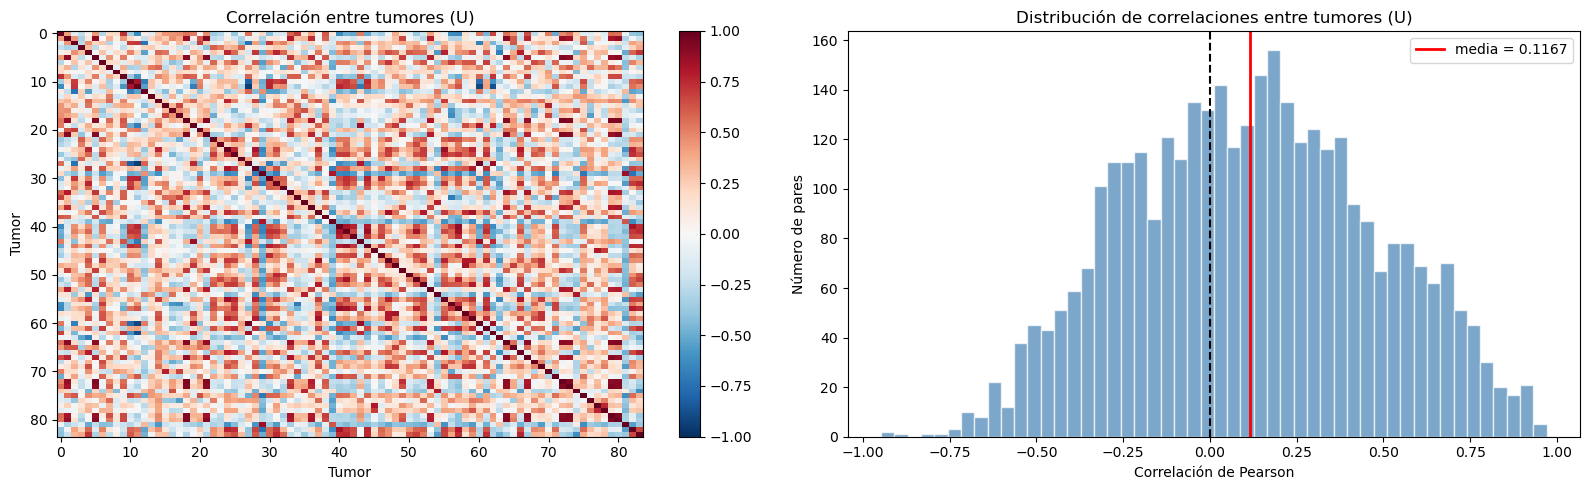

Correlación media: 0.1167
% pares con |corr| > 0.3: 44.2%
% pares con |corr| > 0.5: 19.8%


In [51]:
# Correlación entre tumores (columnas)

corr_U = np.corrcoef(Uv.T)  # (146, 146)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im = axes[0].imshow(corr_U, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[0].set_title('Correlación entre tumores (U)')
axes[0].set_xlabel('Tumor')
axes[0].set_ylabel('Tumor')
plt.colorbar(im, ax=axes[0])

corr_offdiag_U = corr_U[np.triu_indices(n_tum, k=1)]
axes[1].hist(corr_offdiag_U, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].axvline(corr_offdiag_U.mean(), color='red', linewidth=2,
                label=f'media = {corr_offdiag_U.mean():.4f}')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Correlación de Pearson')
axes[1].set_ylabel('Número de pares')
axes[1].set_title('Distribución de correlaciones entre tumores (U)')
axes[1].legend()

plt.tight_layout()
plt.show()
plt.close('all')

print(f"Correlación media: {corr_offdiag_U.mean():.4f}")
print(f"% pares con |corr| > 0.3: {(np.abs(corr_offdiag_U) > 0.3).mean()*100:.1f}%")
print(f"% pares con |corr| > 0.5: {(np.abs(corr_offdiag_U) > 0.5).mean()*100:.1f}%")

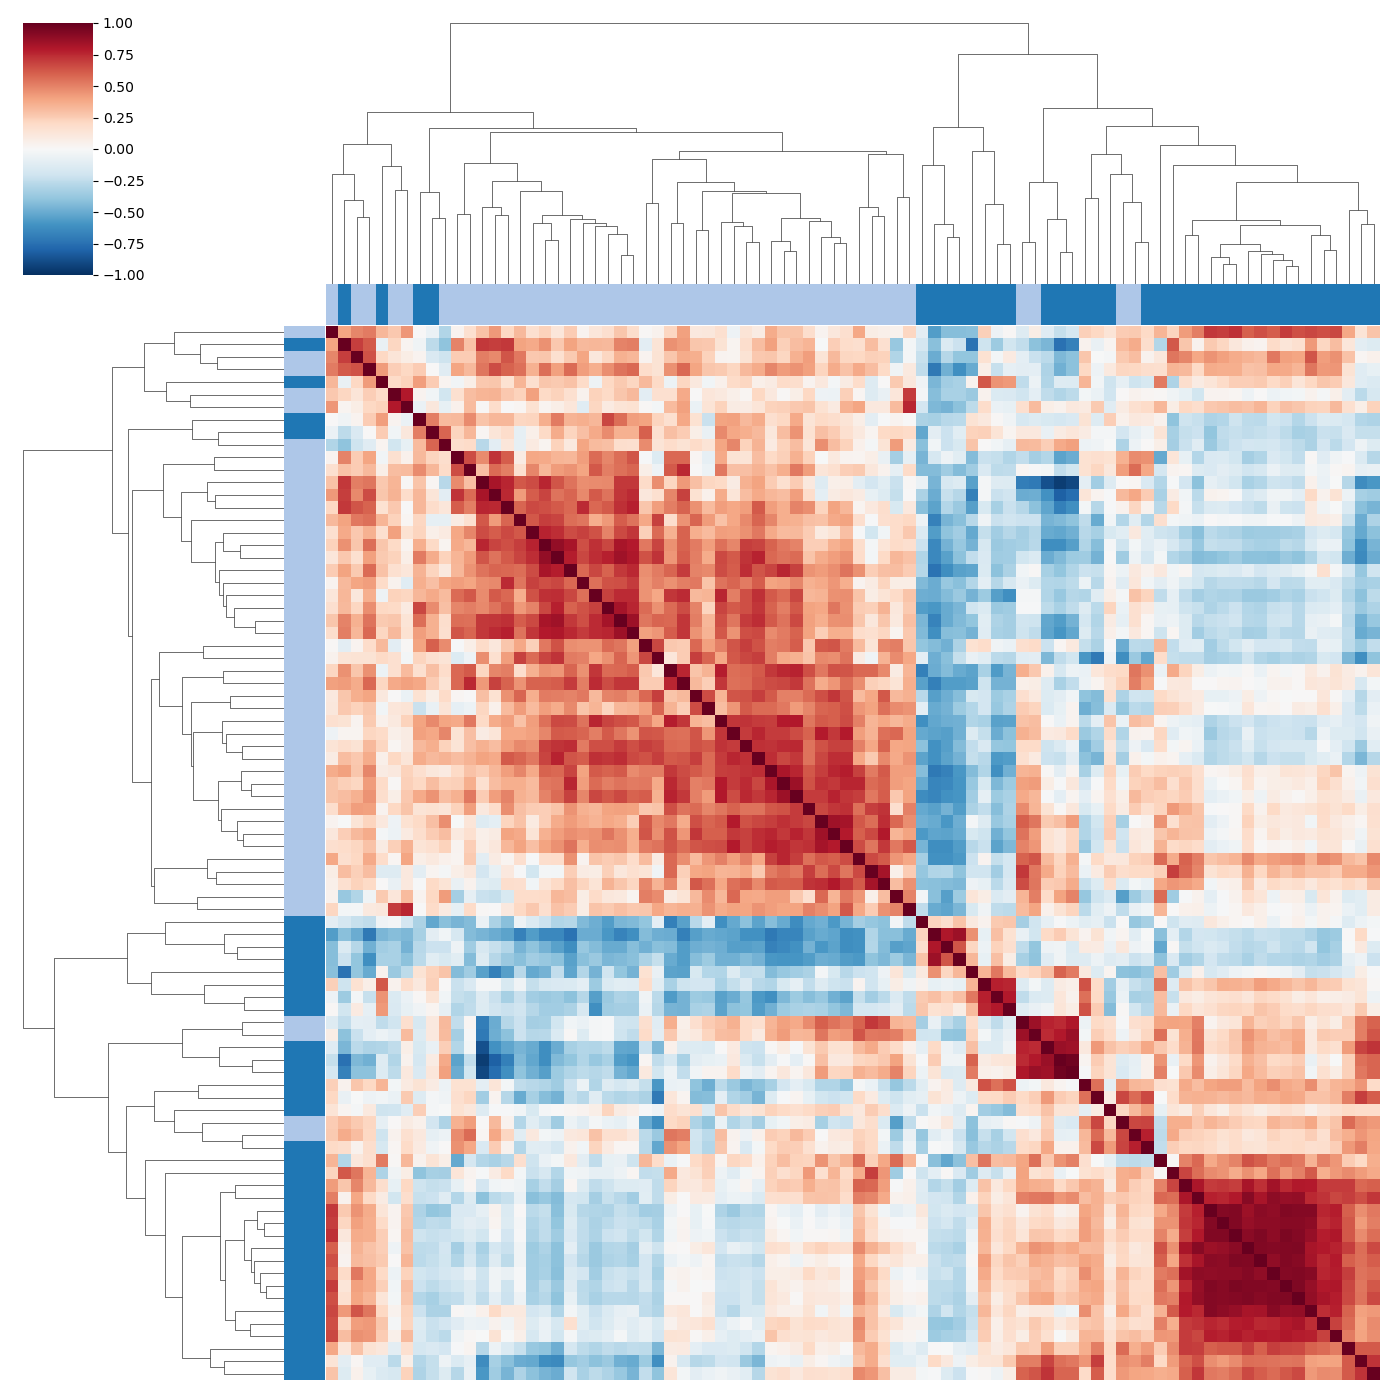

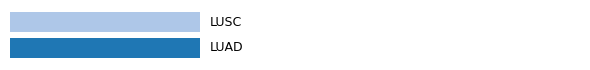

In [52]:
# Clustermap tumores con color por tipo de cáncer
sns.clustermap(pd.DataFrame(corr_U, index=M_df.columns, columns=M_df.columns),
               cmap='RdBu_r', vmin=-1, vmax=1,
               col_colors=col_colors, row_colors=col_colors,
               figsize=(14, 14), xticklabels=False, yticklabels=False)
plt.show()
plt.close('all')

fig, ax = plt.subplots(figsize=(6, len(tipos_unicos) * 0.4))
for i, (tipo, color) in enumerate(color_map.items()):
    ax.barh(i, 1, color=color)
    ax.text(1.05, i, tipo, va='center', fontsize=9)
ax.set_xlim(0, 3)
ax.axis('off')
plt.tight_layout()
plt.show()
plt.close('all')

### Entre tipos de mutación (filas)

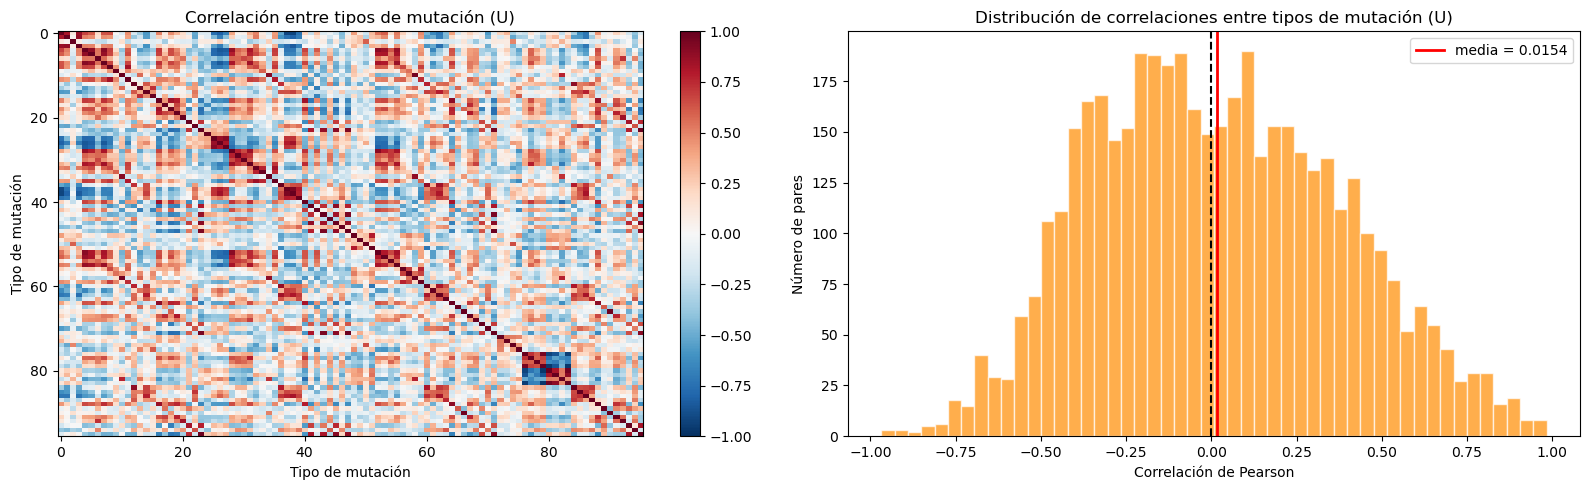

Correlación media: 0.0154
% pares con |corr| > 0.3: 45.4%
% pares con |corr| > 0.5: 16.4%


In [53]:
# Correlación entre tipos de mutación (filas)
corr_U_filas = np.corrcoef(Uv)  # (96, 96)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im = axes[0].imshow(corr_U_filas, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[0].set_title('Correlación entre tipos de mutación (U)')
axes[0].set_xlabel('Tipo de mutación')
axes[0].set_ylabel('Tipo de mutación')
plt.colorbar(im, ax=axes[0])

corr_offdiag_U_filas = corr_U_filas[np.triu_indices(n_mut, k=1)]
axes[1].hist(corr_offdiag_U_filas, bins=50, color='darkorange', alpha=0.7, edgecolor='white')
axes[1].axvline(corr_offdiag_U_filas.mean(), color='red', linewidth=2,
                label=f'media = {corr_offdiag_U_filas.mean():.4f}')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Correlación de Pearson')
axes[1].set_ylabel('Número de pares')
axes[1].set_title('Distribución de correlaciones entre tipos de mutación (U)')
axes[1].legend()

plt.tight_layout()
plt.show()
plt.close('all')

print(f"Correlación media: {corr_offdiag_U_filas.mean():.4f}")
print(f"% pares con |corr| > 0.3: {(np.abs(corr_offdiag_U_filas) > 0.3).mean()*100:.1f}%")
print(f"% pares con |corr| > 0.5: {(np.abs(corr_offdiag_U_filas) > 0.5).mean()*100:.1f}%")

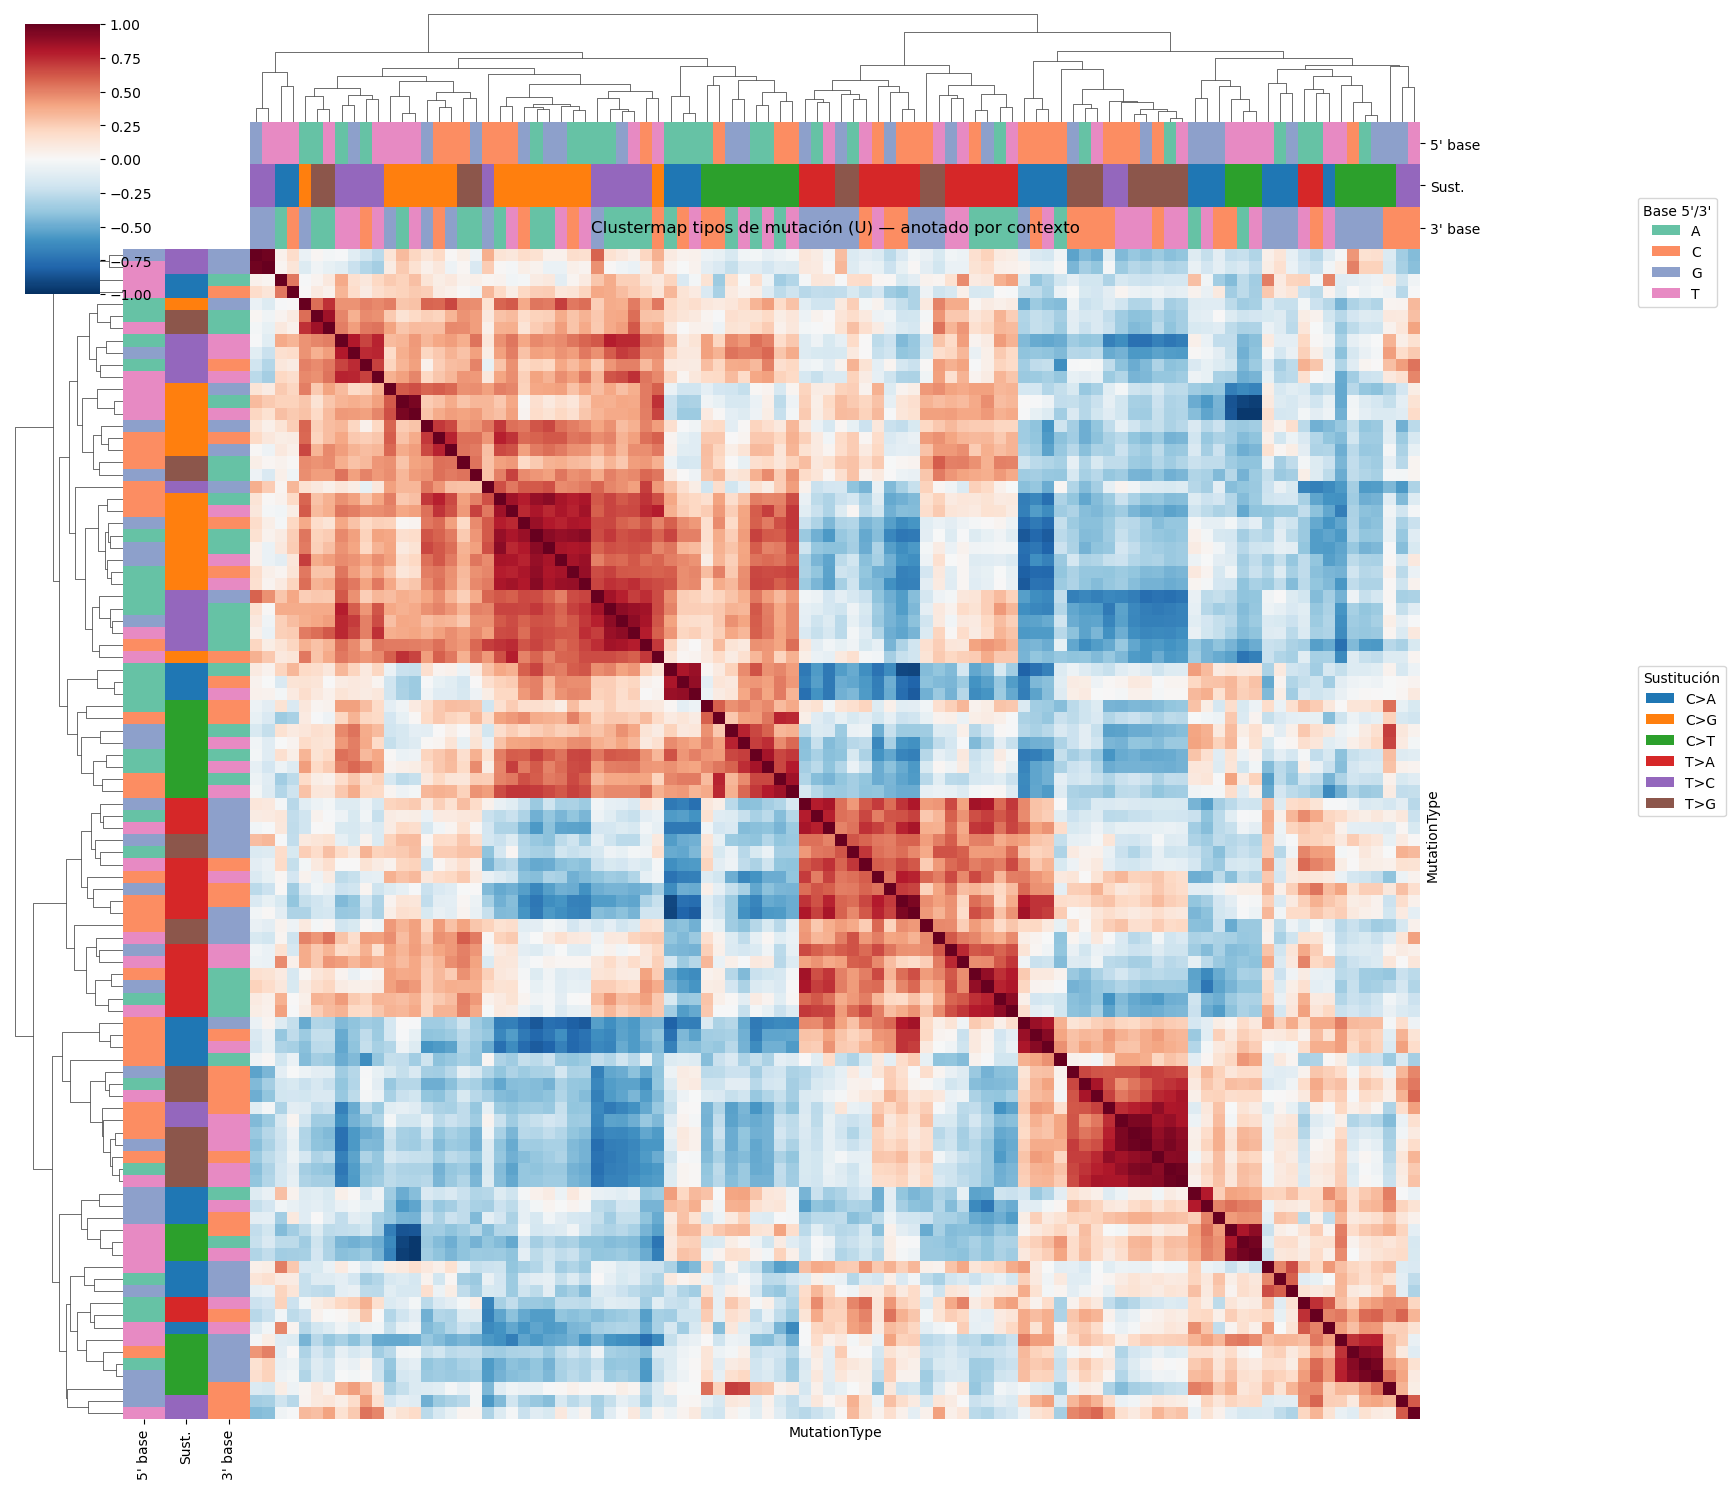

In [54]:
# Clustermap tipos de mutación anotado
g = sns.clustermap(
    pd.DataFrame(corr_U_filas, index=M_df.index, columns=M_df.index),
    cmap='RdBu_r', vmin=-1, vmax=1,
    row_colors=row_colors_df,
    col_colors=row_colors_df,
    figsize=(15, 15),
    xticklabels=False, yticklabels=False,
    dendrogram_ratio=0.08,
)
g.ax_heatmap.set_title('Clustermap tipos de mutación (U) — anotado por contexto', pad=12)
l1 = g.ax_heatmap.legend(handles=leg1, title="Base 5'/3'",
                          loc='upper left', bbox_to_anchor=(1.18, 1.05))
g.ax_heatmap.add_artist(l1)
g.ax_heatmap.legend(handles=leg2, title="Sustitución",
                    loc='upper left', bbox_to_anchor=(1.18, 0.65))
plt.show()
plt.close('all')

# Cálculo de los Residuos

In [55]:
S = S_denovo_df.values.astype(float)      # (96, 8)
A = A_denovo_df.values.T.astype(float)    # (8, 146)

M_hat = S @ A
U = pd.DataFrame(M - M_hat, index=M_df.index, columns=M_df.columns)

print(f"Media residuos (≈ 0): {U.values.mean():.4f}")
print(f"RMSE: {np.sqrt(np.mean(U.values**2)):.4f}")
U

Media residuos (≈ 0): 0.0000
RMSE: 125.6429


,LUAD.US_SP50827,LUAD.US_SP50263,LUAD.US_SP50317,LUAD.US_SP54113,LUSC.US_SP56537,LUAD.US_SP50406,LUSC.US_SP57586,LUAD.US_SP51824,LUAD.US_SP55387,LUAD.US_SP52779,...,LUAD.US_SP52667,LUSC.US_SP57450,LUSC.US_SP57846,LUSC.US_SP58612,LUSC.US_SP56821,LUAD.US_SP51446,LUAD.US_SP50592,LUAD.US_SP53073,LUSC.US_SP58882,LUSC.US_SP57189
MutationType,,,,,,,,,,,,,,,,,,,,,
A[C>A]A,56.609934,17.477874,34.033645,98.194810,180.040742,2.607362,5.627704,-89.294697,100.540099,70.642118,...,-180.157466,30.217709,-137.061715,50.263850,-6.988407,15.341562,12.443101,-43.707425,3.228111,275.859323
A[C>A]C,133.634299,19.721580,-1.417971,17.455824,61.117819,-0.879610,-34.451327,-7.633118,11.129968,-7.158451,...,0.759972,-1.826551,-13.635035,59.586285,-27.938250,34.123143,3.475045,44.245093,-14.381974,36.502827
A[C>A]G,23.783544,0.669809,-27.400736,36.128263,21.234918,-1.769769,-0.494408,1.270574,-13.785430,58.511623,...,-4.236266,5.443152,55.744033,36.056232,-3.789156,2.250120,2.576057,-0.024061,-0.904180,-13.278804
A[C>A]T,67.921087,11.384769,28.438906,-103.376086,113.949869,1.081904,-41.283773,-40.924990,72.227267,45.900227,...,-73.150835,6.532586,-94.307770,-42.176995,-13.230694,12.232222,5.533867,-35.715396,1.444243,-18.446343
A[C>G]A,-31.102043,14.619397,7.974437,216.650824,65.560452,-0.435930,32.859181,-23.897210,28.560290,-108.248562,...,-74.755381,45.361796,-39.291993,1.577420,7.007949,-26.847613,-19.166989,-89.018647,-8.494588,291.492811
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
T[T>C]T,28.806617,-36.269974,18.445850,-57.634953,4.992493,-3.967472,54.108100,-38.014813,7.754857,0.336137,...,-14.657424,35.090418,-39.807984,-86.558538,-30.536639,-22.526655,-0.800686,-32.103475,85.460452,68.704057
T[T>G]A,3.559319,-20.554967,0.379276,-7.238126,5.283746,-1.845832,38.389335,-11.593749,-5.505232,20.778975,...,0.409872,7.220009,-13.165547,-46.409691,-1.563865,-10.423453,-7.742161,-51.744821,3.483619,9.856157
T[T>G]C,-4.915326,-1.453047,0.979803,-38.563528,-15.912881,-1.606693,-7.735294,-14.484194,9.645050,3.352106,...,9.008705,-9.443787,-22.236315,-29.487470,-28.942376,-7.081324,-7.422692,-13.082433,-2.688905,-66.482100


# Análisis de varianza

σ² global:  16919.13

σ² por columnas (tumores):
  min: 21.31,  max: 345072.69,  media: 15952.32
  Ratio max/min: 16194.7x

σ² por filas (tipos de mutación):
  min: 66.73,  max: 250809.52,  media: 15675.34
  Ratio max/min: 3758.5x


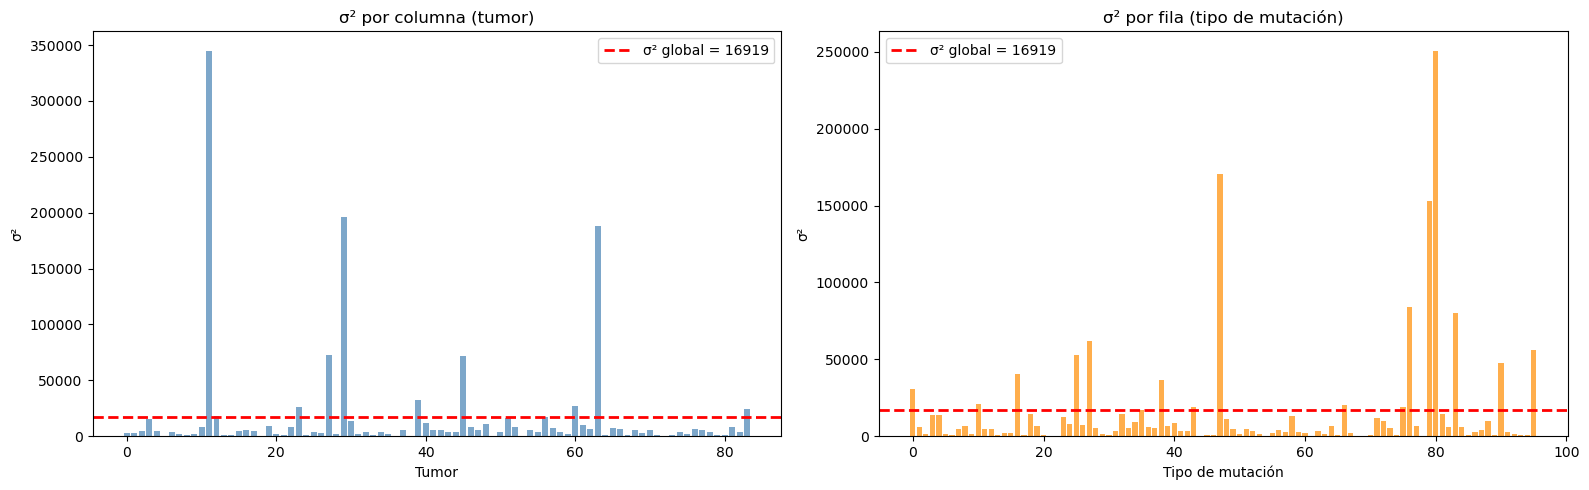

In [56]:
p = S.shape[1] * n_mut + S.shape[1] * n_tum
dof = n_mut * n_tum - p

sigma2_global = np.sum(U.values**2) / dof
sigma2_col = np.var(U.values, axis=0, ddof=1)
sigma2_row = np.var(U.values, axis=1, ddof=1)

print(f"σ² global:  {sigma2_global:.2f}")
print(f"\nσ² por columnas (tumores):")
print(f"  min: {sigma2_col.min():.2f},  max: {sigma2_col.max():.2f},  media: {sigma2_col.mean():.2f}")
print(f"  Ratio max/min: {sigma2_col.max()/sigma2_col.min():.1f}x")
print(f"\nσ² por filas (tipos de mutación):")
print(f"  min: {sigma2_row.min():.2f},  max: {sigma2_row.max():.2f},  media: {sigma2_row.mean():.2f}")
print(f"  Ratio max/min: {sigma2_row.max()/sigma2_row.min():.1f}x")

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(range(n_tum), sigma2_col, color='steelblue', alpha=0.7)
axes[0].axhline(sigma2_global, color='red', linestyle='--', linewidth=2,
                label=f'σ² global = {sigma2_global:.0f}')
axes[0].set_xlabel('Tumor')
axes[0].set_ylabel('σ²')
axes[0].set_title('σ² por columna (tumor)')
axes[0].legend()

axes[1].bar(range(n_mut), sigma2_row, color='darkorange', alpha=0.7)
axes[1].axhline(sigma2_global, color='red', linestyle='--', linewidth=2,
                label=f'σ² global = {sigma2_global:.0f}')
axes[1].set_xlabel('Tipo de mutación')
axes[1].set_ylabel('σ²')
axes[1].set_title('σ² por fila (tipo de mutación)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Variabilidad

In [57]:
Uv = U.values  # numpy array limpio

media_filas = M.mean(axis=1)

VT  = np.sum((M    - media_filas[:, None])**2)
VE  = np.sum((M_hat - media_filas[:, None])**2)
VNE = np.sum((Uv   - Uv.mean(axis=1)[:, None])**2)

print(f"VT  = {VT:.2f}")
print(f"VE  = {VE:.2f}")
print(f"VNE = {VNE:.2f}")
print(f"\n% variabilidad explicada:    {100 * VE / VT:.2f}%")
print(f"% variabilidad no explicada: {100 * VNE / VT:.2f}%")

SS_resid  = np.sum(Uv**2)
SS_total  = np.sum((M - M.mean())**2)
SS_expl   = SS_total - SS_resid

R2 = SS_expl / SS_total

print(f"SS_total  = {SS_total:.2e}")
print(f"SS_expl   = {SS_expl:.2e}")
print(f"SS_resid  = {SS_resid:.2e}")
print(f"\nR² = {R2:.4f}  ({100*R2:.2f}% variabilidad explicada)")
print(f"Residuo relativo (||U||/||M||): {np.linalg.norm(Uv)/np.linalg.norm(M):.4f}")

VT  = 3220943407.69
VE  = 3083925439.20
VNE = 124901095.63

% variabilidad explicada:    95.75%
% variabilidad no explicada: 3.88%
SS_total  = 4.48e+09
SS_expl   = 4.36e+09
SS_resid  = 1.27e+08

R² = 0.9716  (97.16% variabilidad explicada)
Residuo relativo (||U||/||M||): 0.1458


# BOOTSTRAP 

In [25]:
from scipy.optimize import nnls

B = 1000  # número de iteraciones bootstrap
S = S_denovo_df.values.astype(float)  # (96, 8) — fija
n_sig = S.shape[1]

A_boot = np.zeros((B, n_sig, n_tum))  # (1000, 8, 146)

np.random.seed(SEED)

for b in range(B):
    if b % 100 == 0:
        print(f"Bootstrap {b}/{B}...")
    
    # Remuestrear cada tumor por separado
    M_star = np.zeros_like(M)
    for j in range(n_tum):
        counts = M[:, j].astype(int)
        total = counts.sum()
        probs = counts / total
        M_star[:, j] = np.random.multinomial(total, probs)
    
    # Fitting: S fija, encontrar A* con NNLS
    for j in range(n_tum):
        a_star, _ = nnls(S, M_star[:, j])
        A_boot[b, :, j] = a_star

print("Bootstrap completado")

Bootstrap 0/1000...
Bootstrap 100/1000...
Bootstrap 200/1000...
Bootstrap 300/1000...
Bootstrap 400/1000...
Bootstrap 500/1000...
Bootstrap 600/1000...
Bootstrap 700/1000...
Bootstrap 800/1000...
Bootstrap 900/1000...
Bootstrap completado


In [26]:
# Intervalos de confianza al 95%
A_mean  = A_boot.mean(axis=0)                                  # (8, 146)
A_lower = np.percentile(A_boot, 2.5,  axis=0)                 # (8, 146)
A_upper = np.percentile(A_boot, 97.5, axis=0)                 # (8, 146)

print("A_mean shape:", A_mean.shape)
print("IC calculados")

A_mean shape: (3, 84)
IC calculados


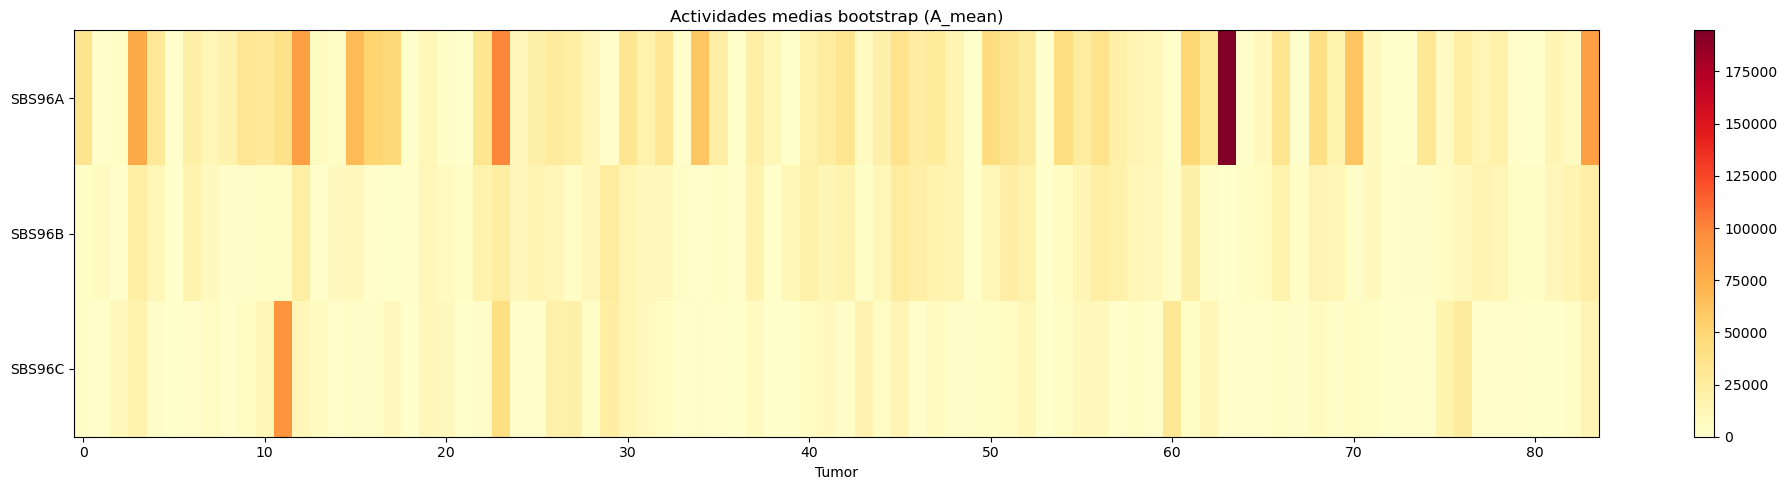

In [34]:
# 1. Heatmap de A_mean — qué firmas dominan en qué tumores
sig_names = S_denovo_df.columns.tolist()
tumor_names = M_df.columns.tolist()

fig, ax = plt.subplots(figsize=(20, 5))
im = ax.imshow(A_mean, aspect='auto', cmap='YlOrRd')
ax.set_yticks(range(n_sig))
ax.set_yticklabels(sig_names)
ax.set_xlabel('Tumor')
ax.set_title('Actividades medias bootstrap (A_mean)')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()
plt.close('all')

In [28]:
# 2. Anchura del IC — qué tumores/firmas tienen más incertidumbre
IC_width = A_upper - A_lower  # (8, 146)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im = axes[0].imshow(IC_width, aspect='auto', cmap='Blues')
axes[0].set_yticks(range(n_sig))
axes[0].set_yticklabels(sig_names)
axes[0].set_xlabel('Tumor')
axes[0].set_title('Anchura IC 95% por firma y tumor')
plt.colorbar(im, ax=axes[0])

# Anchura media por firma
axes[1].barh(sig_names, IC_width.mean(axis=1), color='steelblue', alpha=0.8)
axes[1].set_xlabel('Anchura media IC 95%')
axes[1].set_title('Incertidumbre media por firma')

plt.tight_layout()
plt.show()
plt.close('all')

In [29]:
# 3. Comparar A_mean bootstrap vs A original
A_orig = A_denovo_df.values.T.astype(float)  # (8, 146)

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()

for i, sig in enumerate(sig_names):
    axes[i].scatter(A_orig[i], A_mean[i], alpha=0.6, s=20, color='steelblue')
    lim = max(A_orig[i].max(), A_mean[i].max()) * 1.05
    axes[i].plot([0, lim], [0, lim], 'r--', linewidth=1)
    axes[i].set_title(sig)
    axes[i].set_xlabel('A original')
    axes[i].set_ylabel('A_mean bootstrap')

plt.suptitle('A original vs A_mean bootstrap', y=1.02)
plt.tight_layout()
plt.show()
plt.close('all')

In [30]:
sig_idx = 0

orden = np.argsort(A_mean[sig_idx])[::-1]

err_low  = (A_mean[sig_idx] - A_lower[sig_idx]).clip(0)[orden]
err_high = (A_upper[sig_idx] - A_mean[sig_idx]).clip(0)[orden]

fig, ax = plt.subplots(figsize=(20, 5))
ax.bar(range(n_tum), A_mean[sig_idx][orden], color='steelblue', alpha=0.8)
ax.errorbar(range(n_tum),
            A_mean[sig_idx][orden],
            yerr=[err_low, err_high],
            fmt='none', color='black', capsize=2, linewidth=0.8)
ax.set_xlabel('Tumor (ordenado)')
ax.set_ylabel('Actividad')
ax.set_title(f'Actividad {sig_names[sig_idx]} por tumor ± IC 95%')
plt.tight_layout()
plt.show()
plt.close('all')

In [31]:
sig_idx = 0
top_n = 30

orden = np.argsort(A_mean[sig_idx])[::-1][:top_n]

err_low  = (A_mean[sig_idx] - A_lower[sig_idx]).clip(0)[orden]
err_high = (A_upper[sig_idx] - A_mean[sig_idx]).clip(0)[orden]
labels = [M_df.columns[i].split(".")[0] for i in orden]

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(range(top_n), A_mean[sig_idx][orden], color='steelblue', alpha=0.8, width=0.6)
ax.errorbar(range(top_n),
            A_mean[sig_idx][orden],
            yerr=[err_low, err_high],
            fmt='none', color='black', capsize=4, linewidth=1.2)
ax.set_xticks(range(top_n))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Actividad')
ax.set_title(f'Top {top_n} tumores — actividad {sig_names[sig_idx]} ± IC 95%')
plt.tight_layout()
plt.show()
plt.close('all')

In [32]:
cancer_types = [col.split(".")[0] for col in M_df.columns]
from collections import Counter
counts = Counter(cancer_types)
for tipo, n in sorted(counts.items(), key=lambda x: -x[1]):
    print(f"{tipo}: {n}")

LUSC: 47
LUAD: 37


# ANALISIS 9 FIRMAS

In [41]:
# Cargar solución K=9 del bootstrap residual
base_k9 = os.path.join(BASE, "resultados", "extraccion_residual", "SBS96", 
                        "All_Solutions", "SBS96_9_Signatures")

S_k9_df = pd.read_csv(os.path.join(base_k9, "Signatures", "SBS96_S9_Signatures.txt"), sep="\t", index_col=0)
A_k9_df = pd.read_csv(os.path.join(base_k9, "Activities", "SBS96_S9_NMF_Activities.txt"), sep="\t", index_col=0)

print("S K=9:", S_k9_df.shape)
print("A K=9:", A_k9_df.shape)

S K=9: (96, 9)
A K=9: (84, 9)


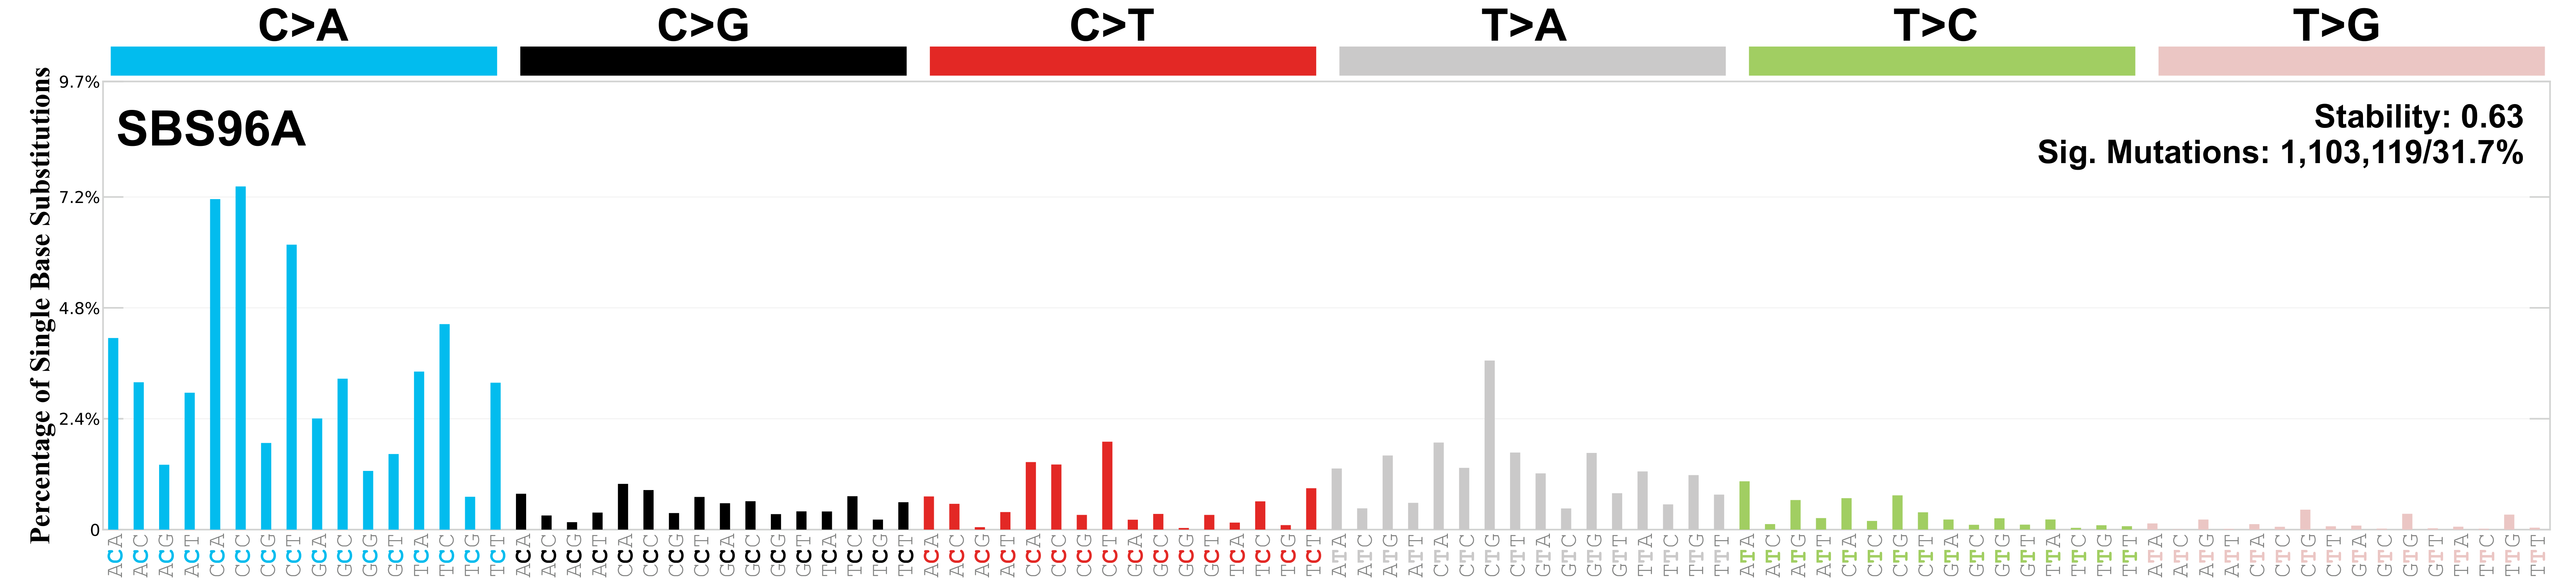

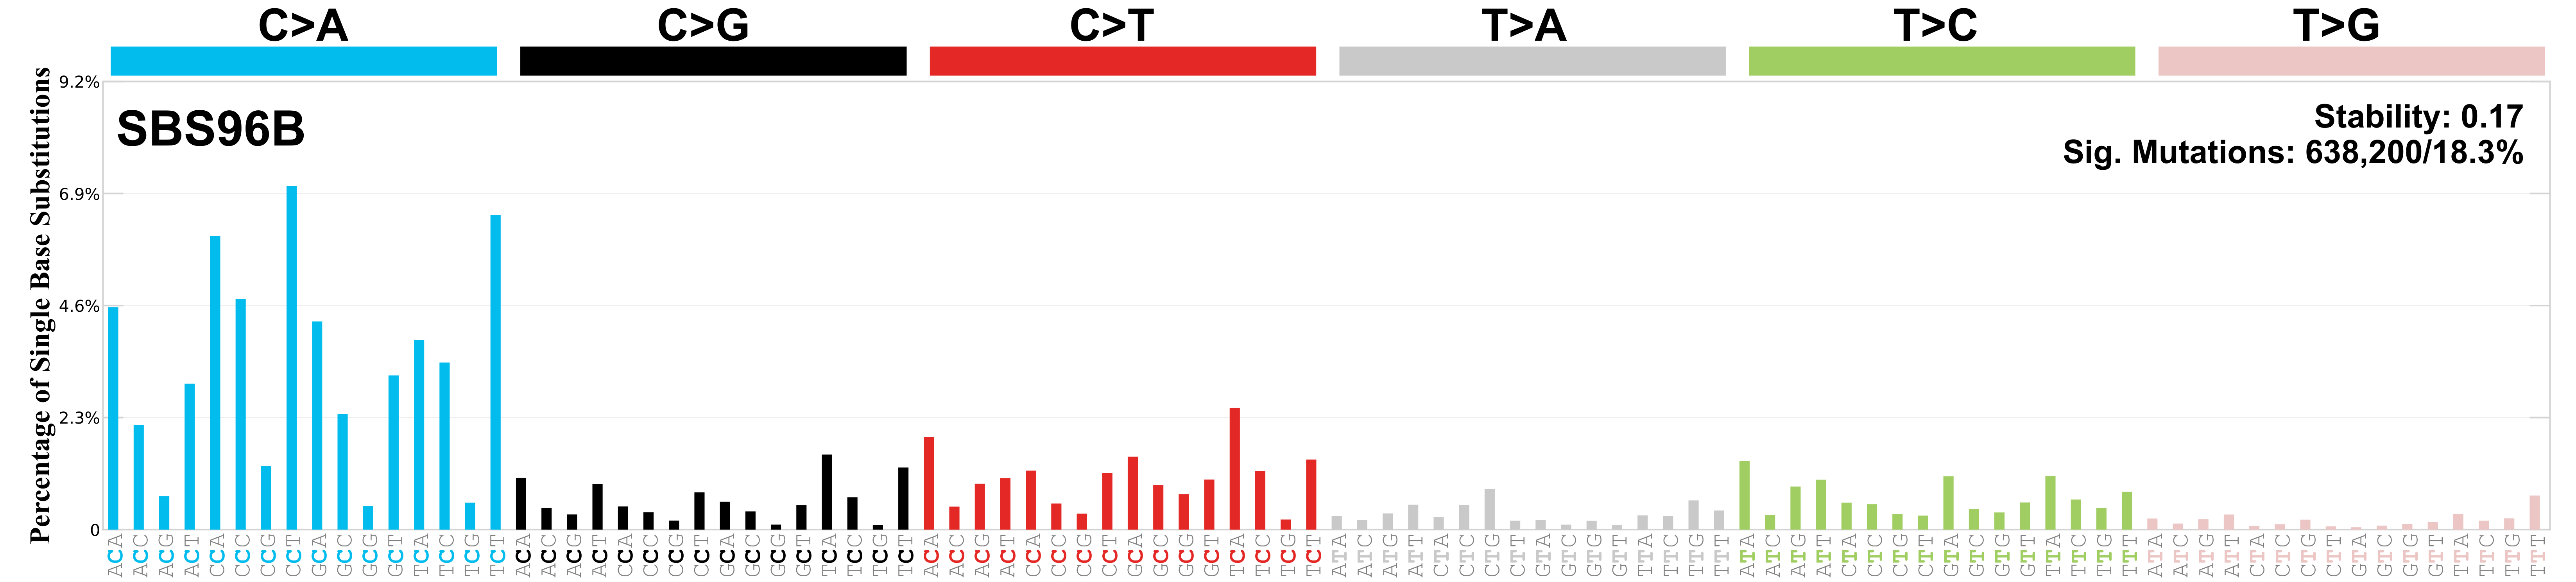

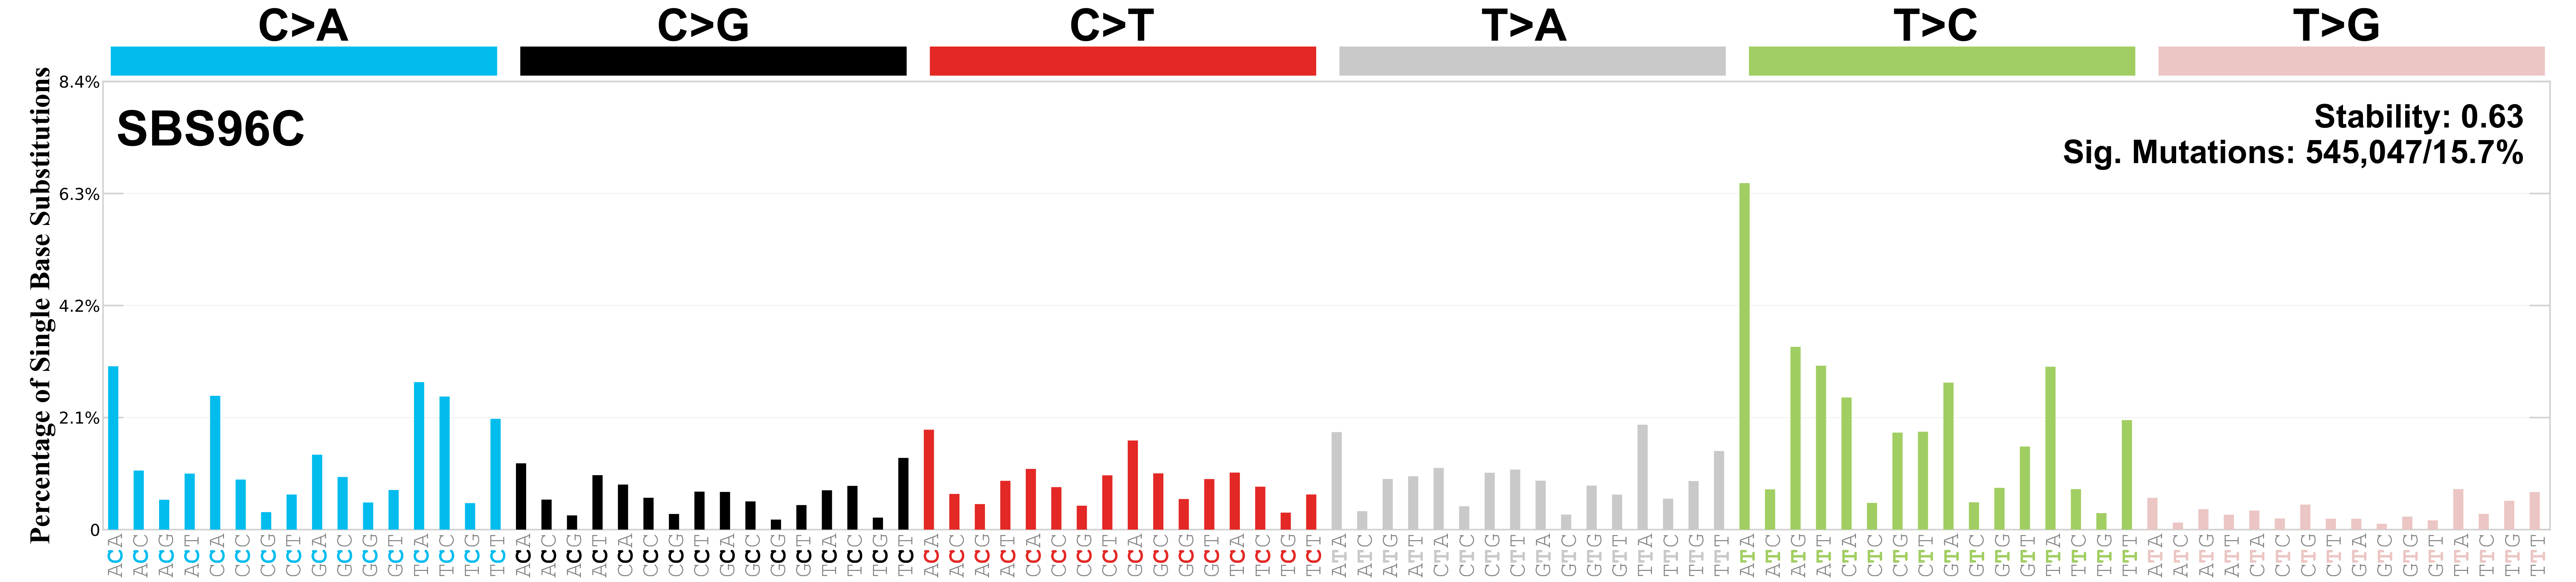

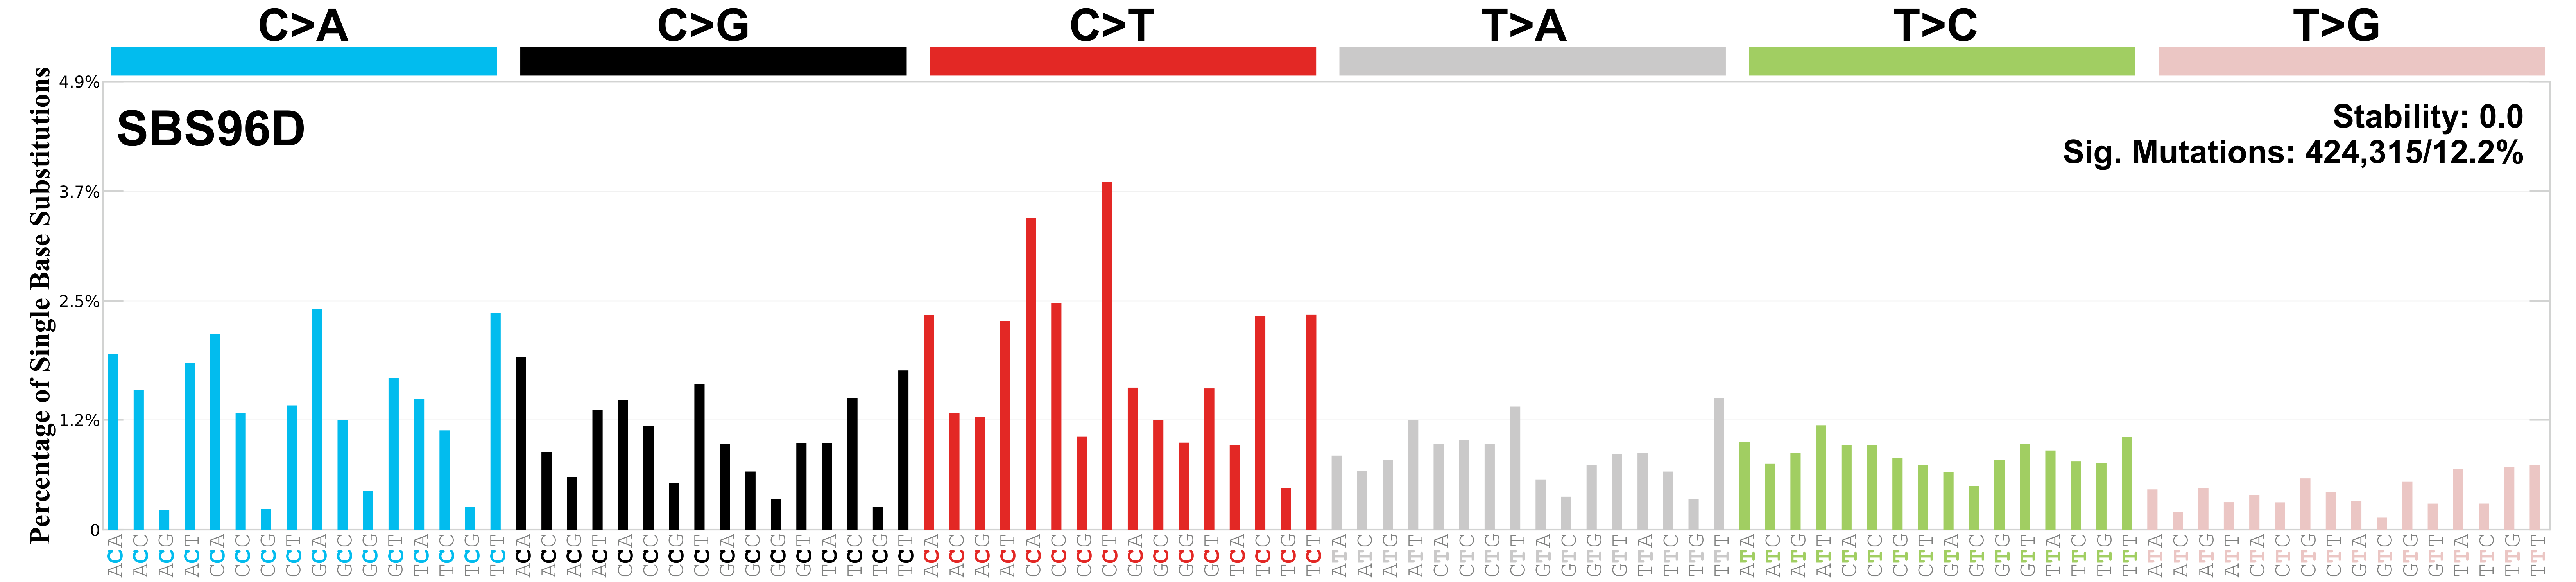

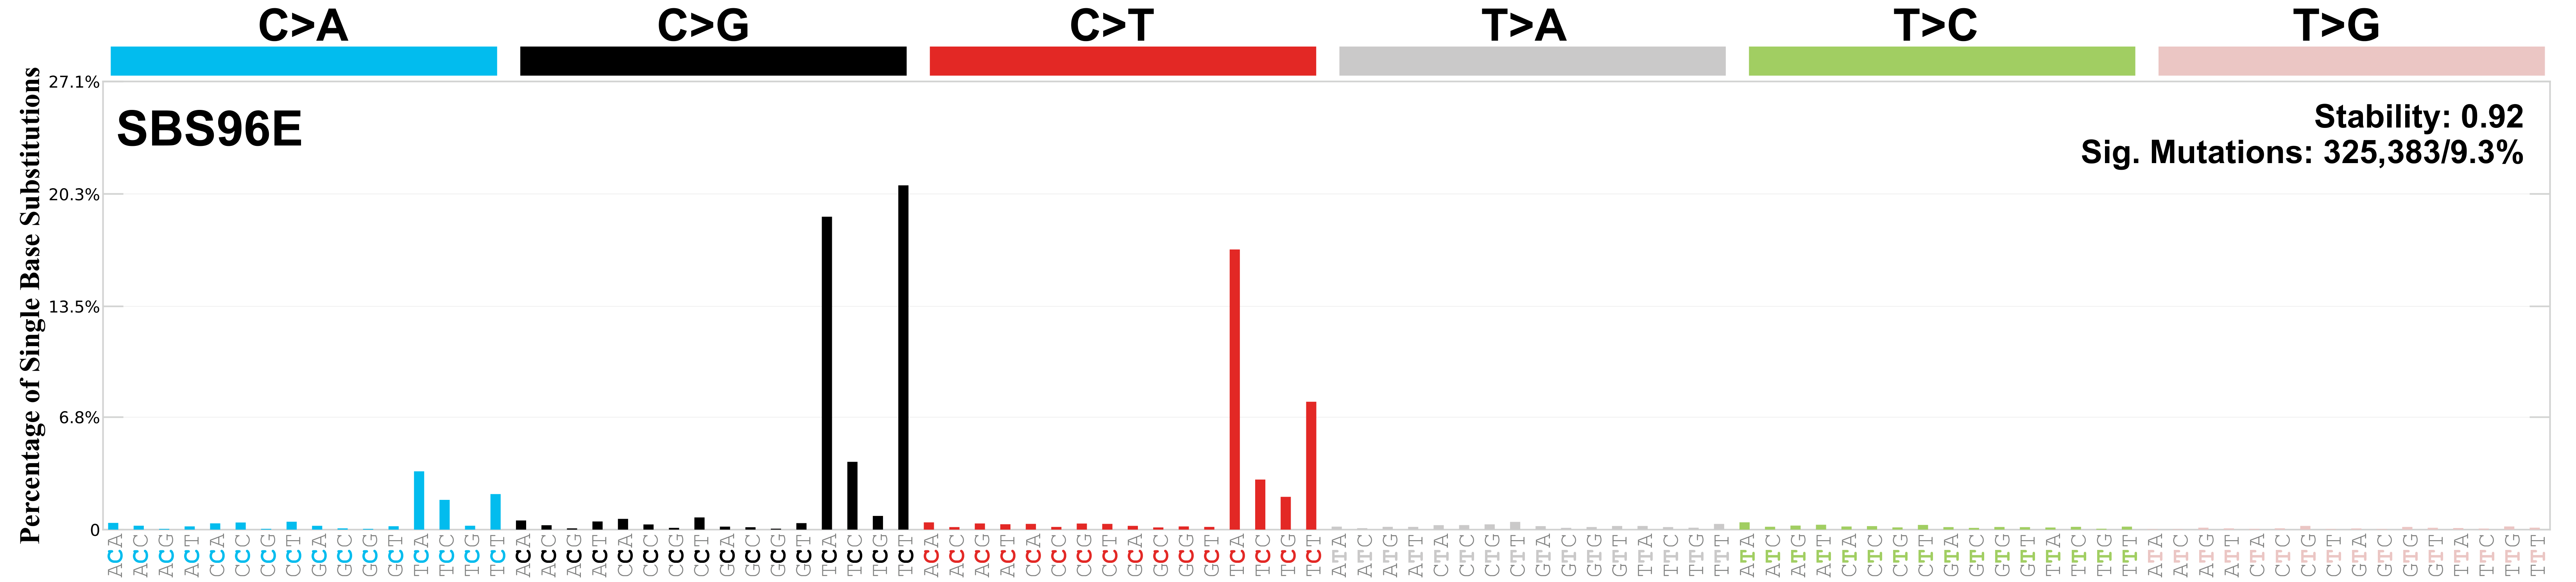

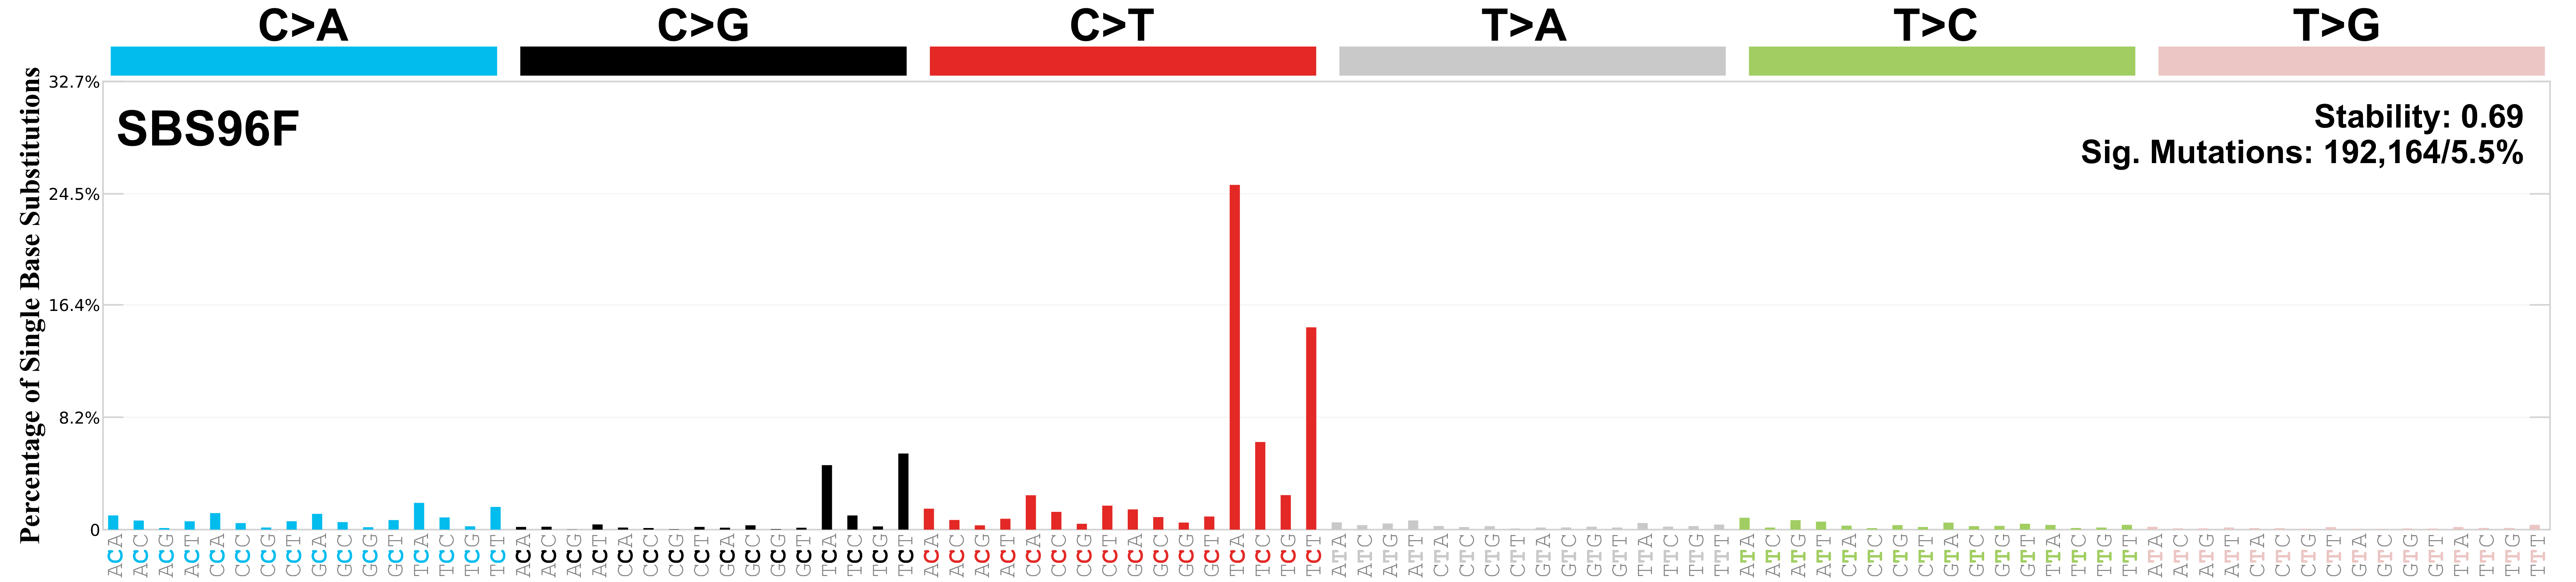

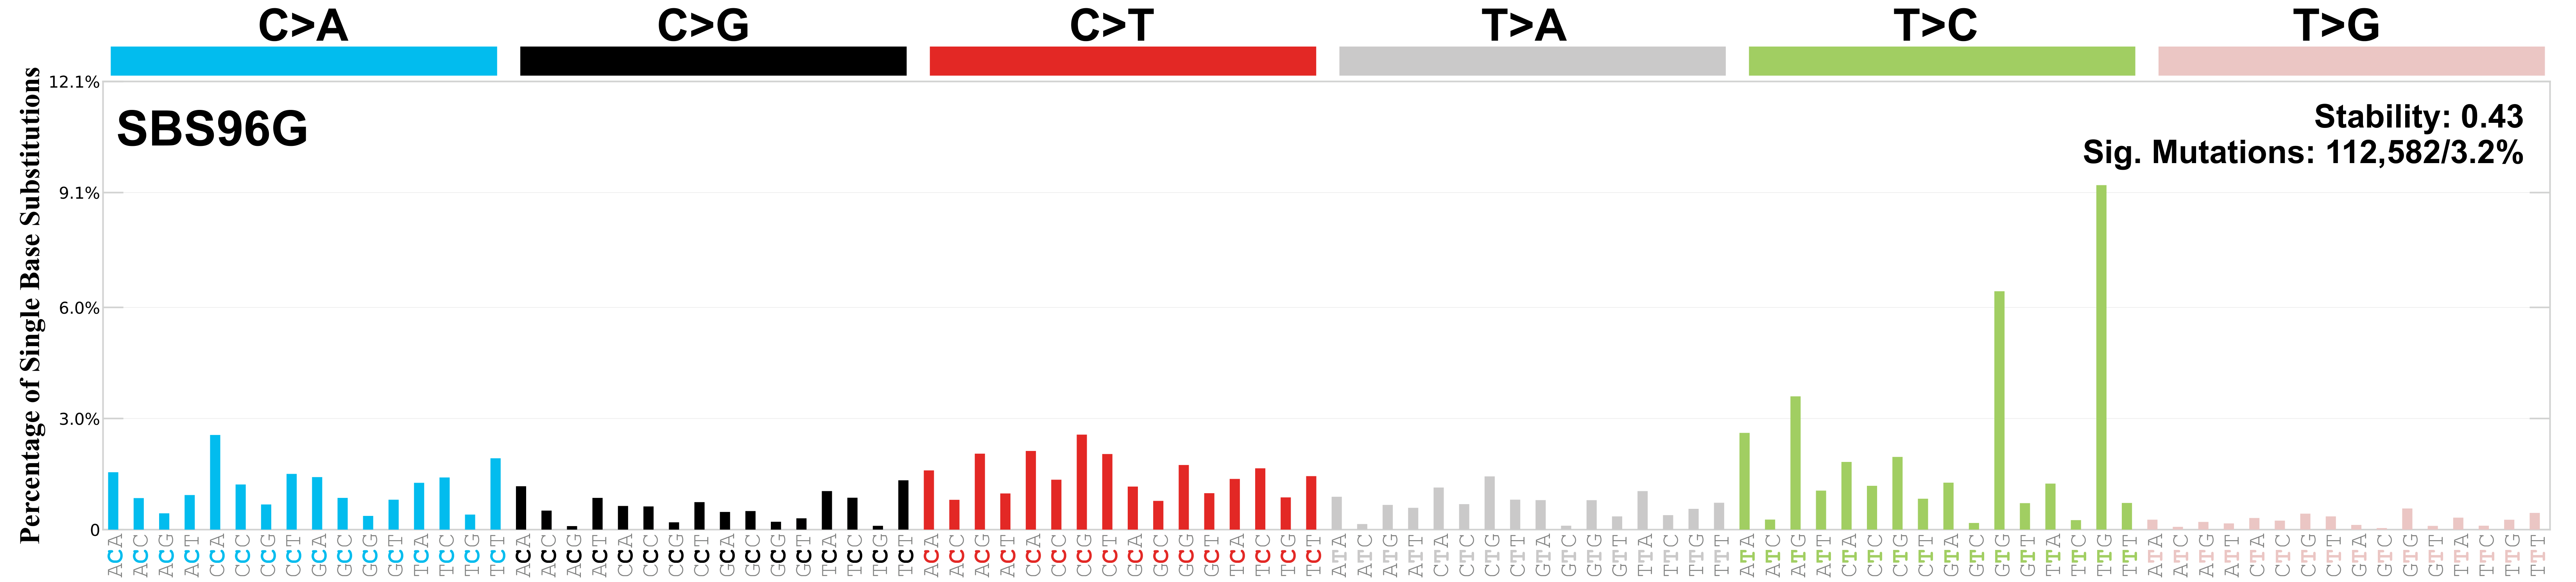

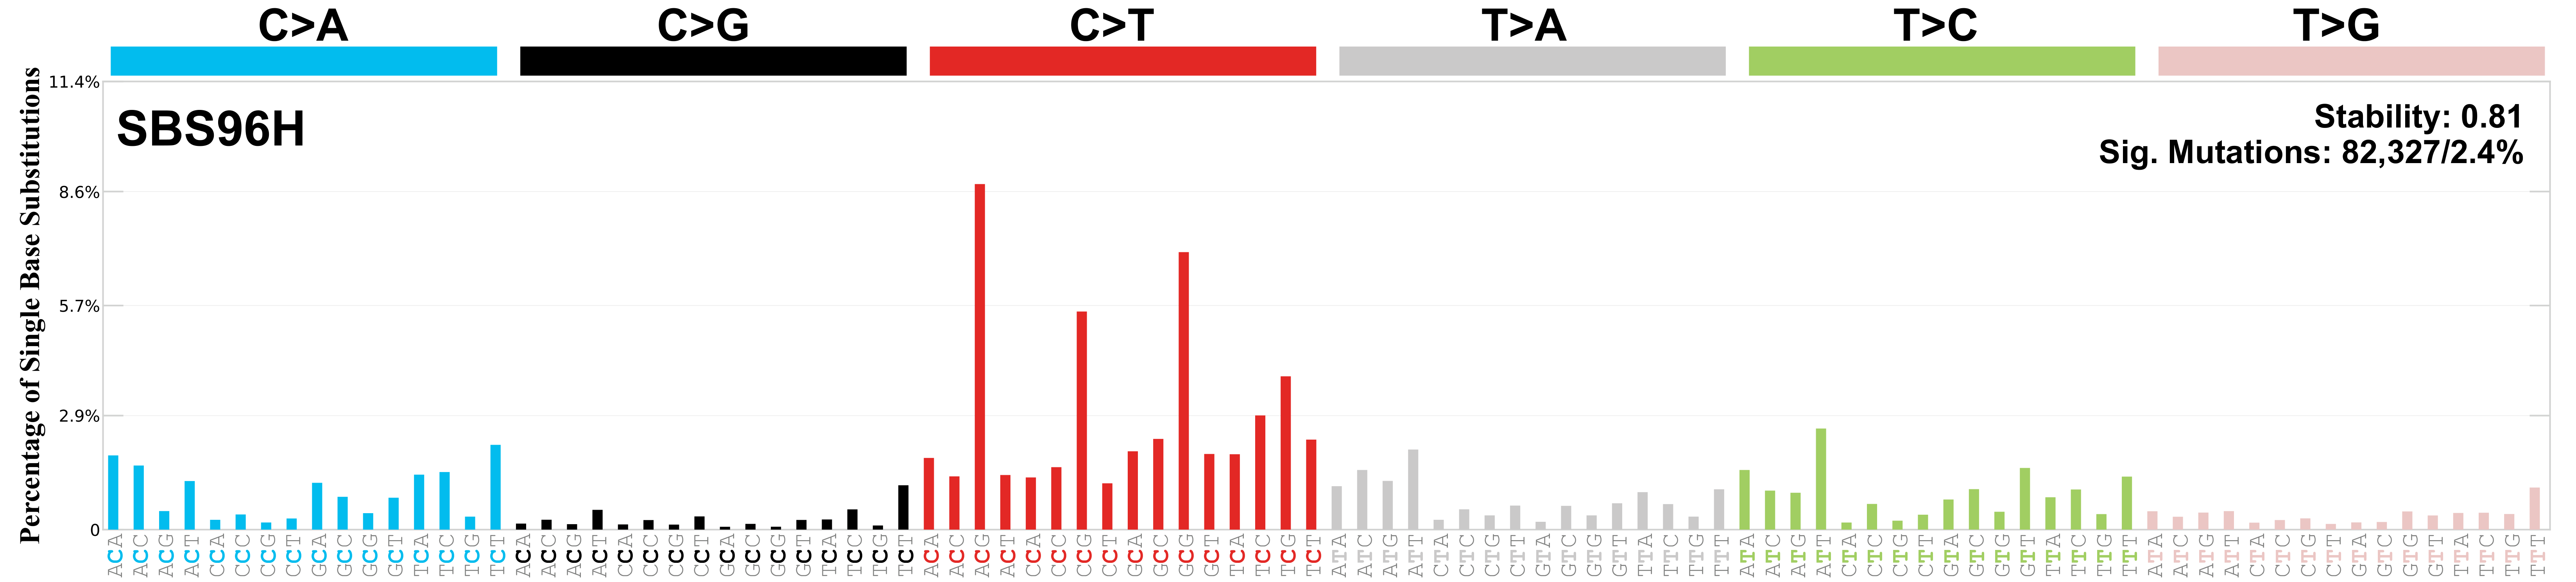

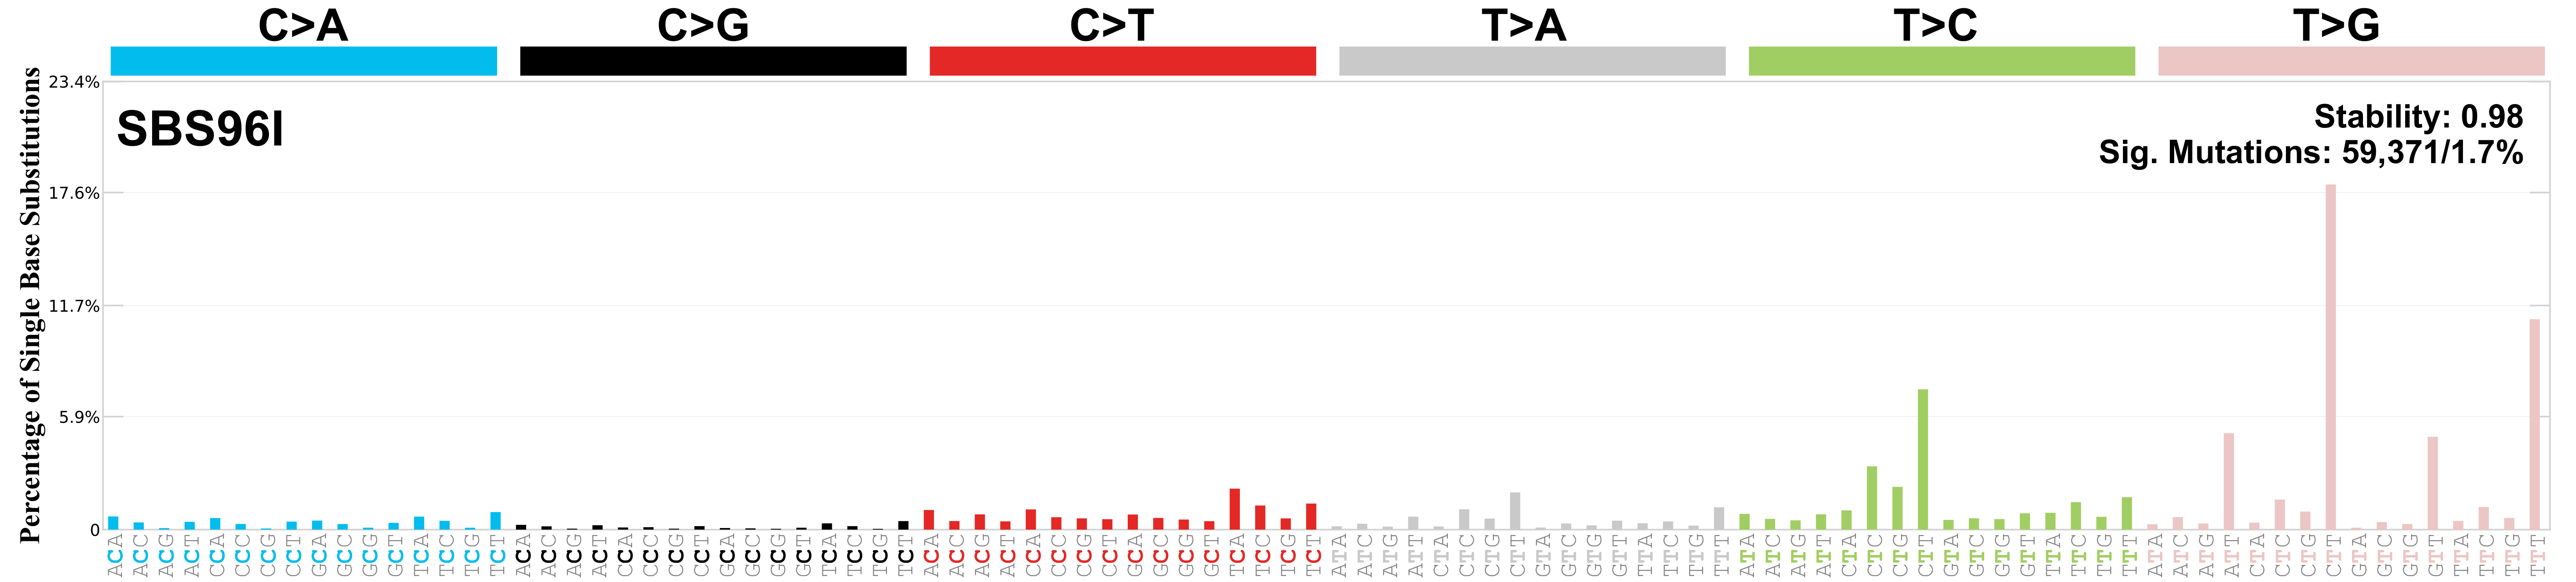

In [45]:
# Firmas de K=9
pdf_path = os.path.join(base_k9, "Signatures", "Signature_plot", "SBS_96_plots_S9.pdf")
doc = fitz.open(pdf_path)
for page in doc:
    pix = page.get_pixmap(dpi=150)
    display(Image(data=pix.tobytes("png"), format='png'))

In [46]:
# Residuos de K=9
S_k9 = S_k9_df.values.astype(float)
A_k9 = A_k9_df.values.T.astype(float)
M_hat_k9 = S_k9 @ A_k9
U_k9 = M - M_hat_k9

print(f"Media residuos K=9: {U_k9.mean():.4f}")
print(f"RMSE K=9: {np.sqrt(np.mean(U_k9**2)):.4f}")

sigma2_col_k9 = np.var(U_k9, axis=0, ddof=1)
sigma2_row_k9 = np.var(U_k9, axis=1, ddof=1)
print(f"\nσ² por columnas — min: {sigma2_col_k9.min():.2f}, max: {sigma2_col_k9.max():.2f}, media: {sigma2_col_k9.mean():.2f}")
print(f"σ² por filas   — min: {sigma2_row_k9.min():.2f}, max: {sigma2_row_k9.max():.2f}, media: {sigma2_row_k9.mean():.2f}")

Media residuos K=9: -0.0000
RMSE K=9: 56.8814

σ² por columnas — min: 6.23, max: 34924.16, media: 3269.55
σ² por filas   — min: 28.62, max: 23635.71, media: 2809.85


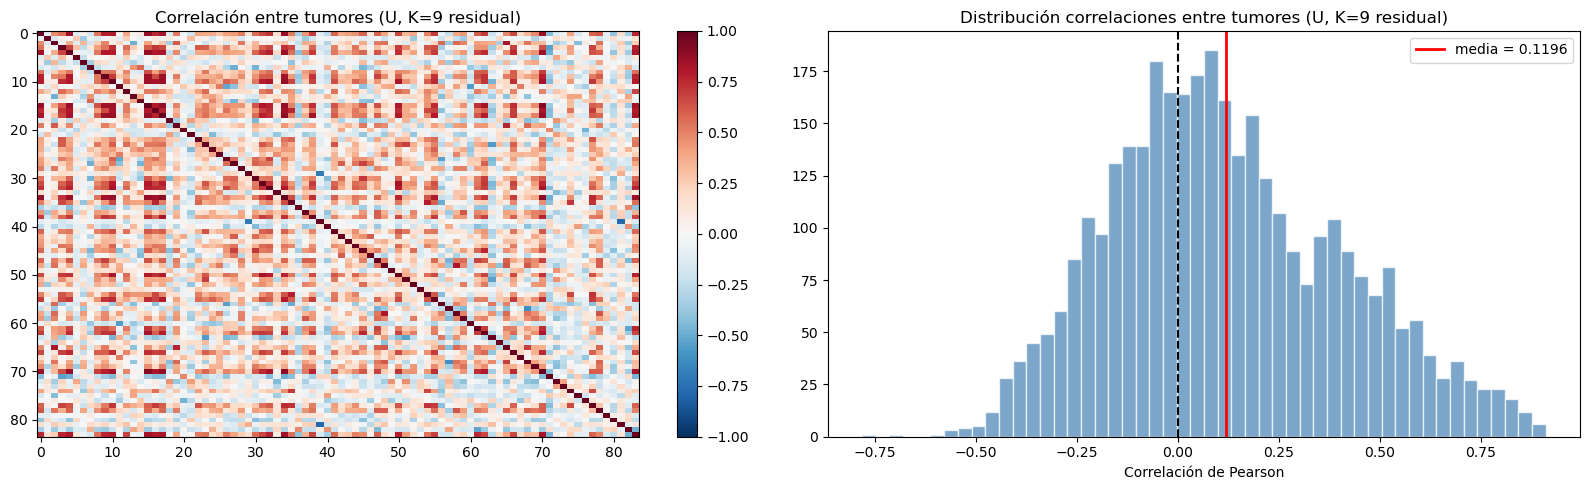

In [47]:
# Correlación entre tumores para K=9
corr_U_k9 = np.corrcoef(U_k9.T)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
im = axes[0].imshow(corr_U_k9, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[0].set_title('Correlación entre tumores (U, K=9 residual)')
plt.colorbar(im, ax=axes[0])

corr_offdiag_k9 = corr_U_k9[np.triu_indices(n_tum, k=1)]
axes[1].hist(corr_offdiag_k9, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].axvline(corr_offdiag_k9.mean(), color='red', linewidth=2,
                label=f'media = {corr_offdiag_k9.mean():.4f}')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].legend()
axes[1].set_xlabel('Correlación de Pearson')
axes[1].set_title('Distribución correlaciones entre tumores (U, K=9 residual)')
plt.tight_layout()
plt.show()

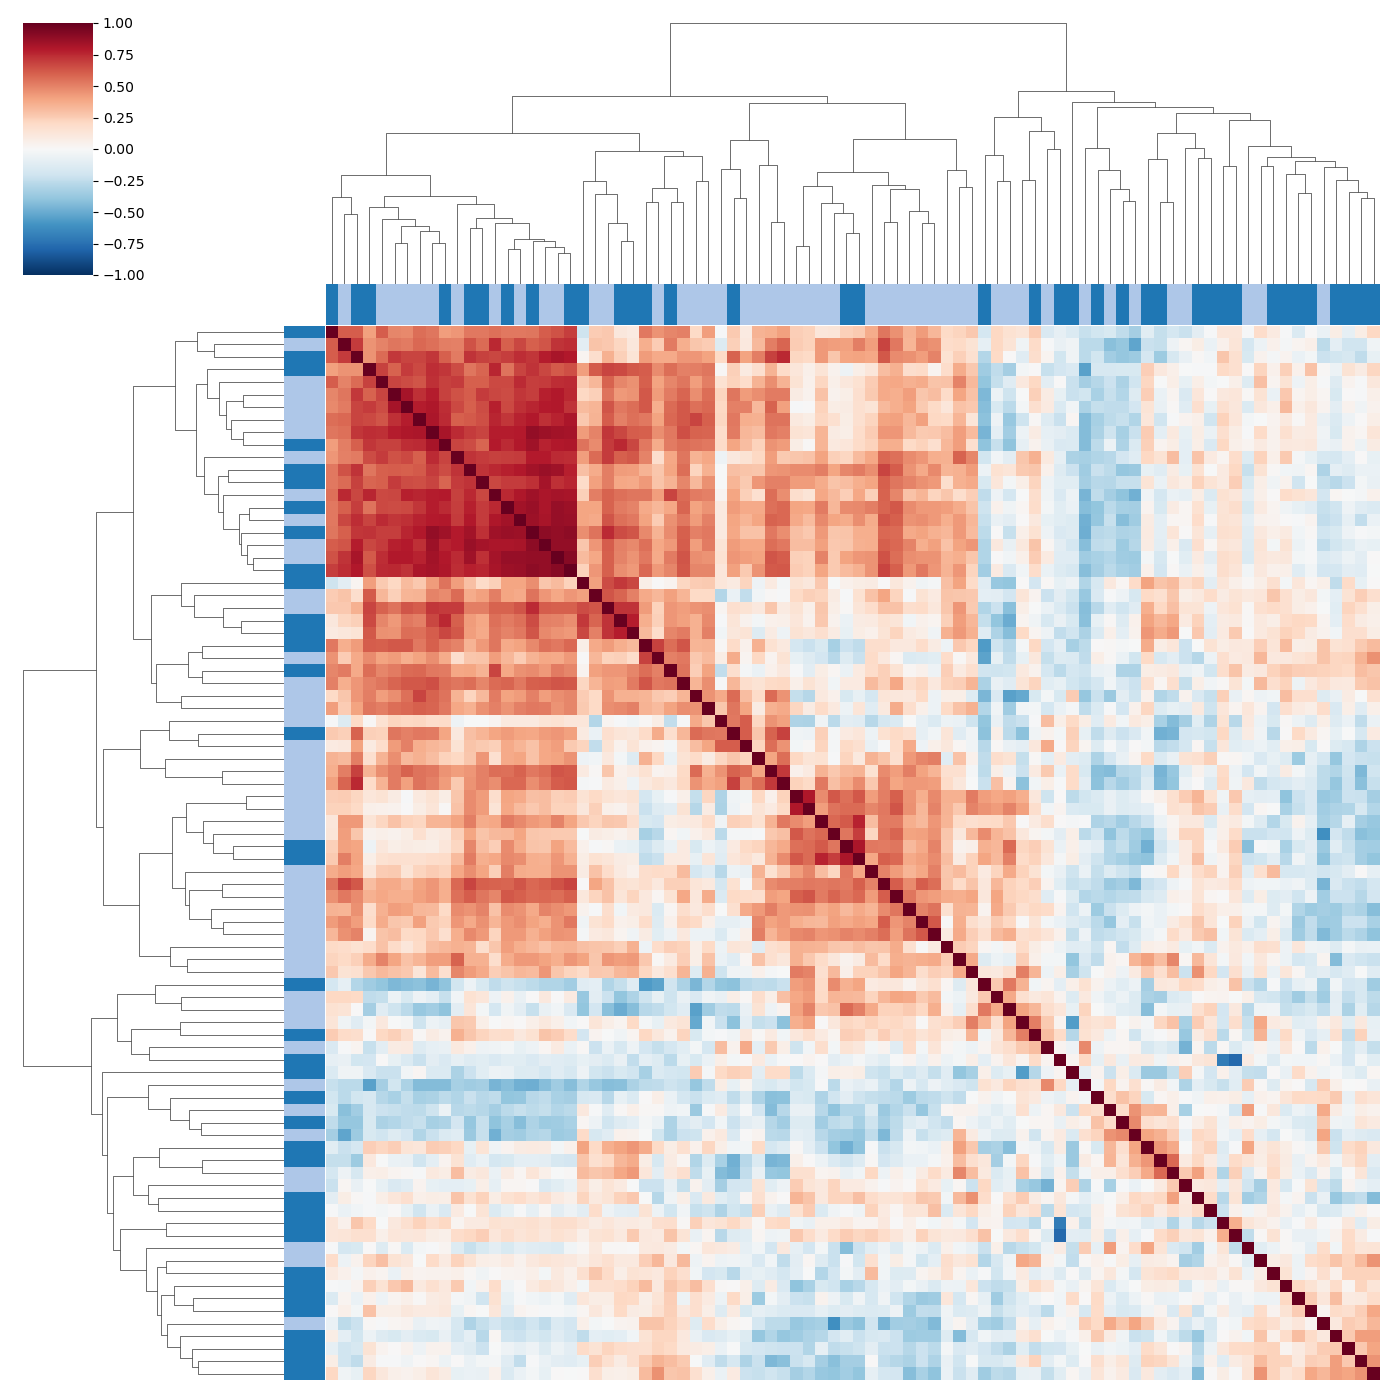

In [48]:
import seaborn as sns

cancer_types_list = [col.split(".")[0] for col in M_df.columns]
tipos_unicos = list(set(cancer_types_list))
palette = sns.color_palette("tab20", len(tipos_unicos))
color_map = dict(zip(tipos_unicos, palette))
col_colors = [color_map[t] for t in cancer_types_list]

S_k9 = S_k9_df.values.astype(float)
A_k9 = A_k9_df.values.T.astype(float)
M_hat_k9 = S_k9 @ A_k9
U_k9 = M - M_hat_k9

corr_U_k9 = np.corrcoef(U_k9.T)

sns.clustermap(pd.DataFrame(corr_U_k9, index=M_df.columns, columns=M_df.columns),
               cmap='RdBu_r', vmin=-1, vmax=1,
               col_colors=col_colors, row_colors=col_colors,
               figsize=(14, 14), xticklabels=False, yticklabels=False)
plt.show()
plt.close('all')

In [58]:
corr_offdiag_k9 = corr_U_k9[np.triu_indices(n_tum, k=1)]
print(f"Correlación media: {corr_offdiag_k9.mean():.4f}")
print(f"% pares con |corr| > 0.3: {100 * np.mean(np.abs(corr_offdiag_k9) > 0.3):.1f}%")
print(f"% pares con |corr| > 0.5: {100 * np.mean(np.abs(corr_offdiag_k9) > 0.5):.1f}%")

Correlación media: 0.1196
% pares con |corr| > 0.3: 32.0%
% pares con |corr| > 0.5: 12.2%
